# Unsupervised Clustering of Hotel Bookings

**Segmenting Business and Leisure Travellers Based on Booking Characteristics**

*Unsupervised Learning · 2025/2026 · Group 3 — P2*

| | |
|---|---|
| **Team** | Rogério Soares (73803), Guilherme Simões (74154), Vasco Horta (73476) |
| **Repository** | <span style="color: #C2410C; font-weight: 600">[fill in: GitHub URL]</span> |
| **Repository version** | <span style="color: #C2410C; font-weight: 600">[fill in: commit hash / tag / branch]</span> |
| **Dataset** | `hotel_bookings_course_release_v1.csv` (course release v1) |
| **AI tools disclosure** | <span style="color: #C2410C; font-weight: 600">[fill in: e.g. "GenAI used for methodological consultation and syntax review only; no substantive code, text or analysis was generated by AI tools."]</span> |

---

This notebook is the canonical project notebook. It is organised around the
**seven-section project template** for Milestone 2 and grows into the full
final-submission scope (Tasks 1–4 of the project brief).

**Reading map (follows Brief Task 1/2/3/4 spine):**

- The notebook spine is the Brief's Task 1 / Task 2 / Task 3 / Task 4.
- **Task 1.1** (data prep + EDA + representation) and **Task 1.2** (k-means + iK-means baseline) are fully executed.
- **Task 2** (alternative family) scaffolds Ward, GMM, and DBSCAN. Ward is the recommended primary alternative; GMM is the conceptual contrast; DBSCAN is the explicit negative-result section.
- **Task 3** consolidates internal indices (3.1), family-specific diagnostics (3.2), stability and four planned preprocessing variants (3.3), and the final cluster narrative (3.4). The 3.3 protocol is executed for the baseline; variants are scaffolded.
- **Task 4** is the report (4.1, outside the notebook) and the experiment-log + repository scaffolding (4.2). The logging helper is built *physically early* in the notebook (right before Task 1.2) because the Task 1.2 fits need to log through it.

**Mapping back to the Milestone 2 template (for the mid-term deliverable):**

| Template § | Where it lives in this notebook |
|---|---|
| §1 RQ1 + segmentation time | §Task 1.1.1 |
| §2 Dataset version control | §Task 1.1.2 |
| §3 EDA | §Task 1.1.3 |
| §4 Main representation | §Task 1.1.4 |
| §5 Baseline modelling | §Task 1.2 |
| §6 Sensitivity / robustness plan | §Task 3.3 + §Task 3.3-Protocol |
| §7 Experiment logging | §Experiment logging (built before Task 1.2) and §Task 4.2 |

Sources cross-referenced throughout:

- **Brief** = `Project_AssignmentBrief_HotelBookingDemand.pdf` (the official project brief)
- **Guidance** = `HotelBooking_Milestone2_Revised.pdf` (Prof. Nascimento's Milestone 2 preprocessing slides)
- **Spec** = `Project_Specification_for_Unsupervised_Learning.pdf` (our Group 3 — P2 specification)
- **Template** = `Project_TemplateMilestone2_ANSup26.pdf` (the Milestone 2 deliverable template)

## Imports and global configuration

Single import block at the top so the rest of the notebook is uncluttered.
All algorithms, metrics, preprocessing, and the iK-means module are imported
once here.

In [45]:
# --- Standard library ----------------------------------------------------
import os
import json
import math
import time
import uuid
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone
from itertools import combinations

# --- Scientific stack ----------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import contingency

# --- scikit-learn --------------------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)

# --- iK-means module (Mirkin AP initialisation) --------------------------
# Lives in the project repository under modules/ikmeans/
from modules.ikmeans.ikmeans import (
    APCluster,
    ikmeans_initialize,
    compute_feature_statistics,
)

# --- Notebook hygiene ----------------------------------------------------
warnings.filterwarnings('ignore')
np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

os.makedirs('artifacts', exist_ok=True)
os.makedirs('plots', exist_ok=True)

---

# Task 1 — Baseline Study

> **Brief §Task 1.** Two parts: the data preparation and validation pipeline (1.1) and the baseline clustering model (1.2).

# Task 1.1 — Data preparation and validation pipeline

> **Brief §1.1.** *"State the concrete segmentation question (RQ1) and the unit of analysis, then produce a short data documentation. Report missingness and outliers by attribute type. Build an end-to-end preprocessing pipeline. Define the final feature set and the similarity/distance implied by the final representation; document all exclusions (especially leakage control)."*

Task 1.1 has five sub-tasks in this notebook:

| Sub-task | Content |
|---|---|
| 1.1.1 | RQ1, unit of analysis, segmentation (index) time, ADR decision |
| 1.1.2 | Dataset version control, SHA-256 fingerprint, license, known issues |
| 1.1.3 | EDA — missingness, outliers, univariate / pairwise / hotel-split / seasonality |
| 1.1.4 | Main representation — feature selection, log1p + scaling + OHE pipeline, metric sentence, representation_id artefact, two-bookings worked example |

---

# Task 1.1.1 — RQ1 and segmentation time

> **Template §1 — required content:** state the concrete segmentation question, the unit of analysis, and the segmentation time (index time) assumed for clustering inputs.

### Project title

**Unsupervised Clustering of Hotel Bookings: Segmenting Business and Leisure Travellers Based on Booking Characteristics** (Spec §1).

### RQ1 — segmentation question

**From our project specification (Spec §3):**

> *"We will segment hotel guests into travel-purpose clusters using features like lead time, length of stay, booking day of week, number of adults, children, babies and seasonality to identify if natural business or leisure patterns emerge from booking data."*

**Methodological reframe for the unsupervised setting.** Because we have no labels for travel purpose, we *cannot* state up front that the project will partition guests into business and leisure groups. The honest unsupervised question is:

> *Can hotel bookings be partitioned into stable, interpretable profiles using features known at booking creation, and do any of these profiles plausibly capture leisure-vs-business travel patterns?*

This is faithful to RQ1 in Brief §3 — *"What is the concrete segmentation question, and why is clustering an appropriate tool?"* — without presupposing a clean dichotomy that the data may not support.

### Unit of analysis

One row = **one booking record** (Brief §Dataset). The same guest may appear in multiple rows; bookings, not unique guests, are the entities being clustered.

### Segmentation time (index time)

All clustering inputs are restricted to information available **at booking creation**, in line with Guidance slides 7–8 ("eligibility test: could the hotel know this exact value at the segmentation time?").

- **Allowed as inputs:** `lead_time`, intended arrival period (year/month/week/day), `reserved_room_type`, stay length, party composition, `meal`, `market_segment`, `distribution_channel`, `customer_type`, `deposit_type`, previous-customer history, `total_of_special_requests` recorded at booking, `adr` at the booked rate.
- **Profiling-only (post-hoc):** `is_canceled`, `reservation_status`, `reservation_status_date` — these are *outcome* fields realised after the booking.
- **Excluded entirely:** `assigned_room_type`, `days_in_waiting_list`, `booking_changes` (post-booking operations that violate the index-time rule), and the ID-like `agent` / `company`.

### Why clustering (RQ1 justification)

Per Spec §3: (1) there are no predefined labels; (2) clustering discovers groupings empirically from booking patterns rather than imposing assumed categories; (3) it can reveal micro-segments that a binary business-vs-leisure rule would miss.

### ADR decision — **kept as a clustering input** with a planned sensitivity check

Guidance slides 23–24 are explicit: including ADR in clustering inputs means *the distance measures commercial-value similarity as well as booking-behaviour similarity*. Our team decision is to **keep ADR in the main representation** (rationale: our spec explicitly cites the business/leisure ADR gap as a motivating finding, so price is part of the segmentation signal we want to investigate) and **report a `withADR` vs `noADR` sensitivity comparison in §6** to quantify how much of the cluster structure is driven by price versus behaviour.

---

# Task 1.1.2 — Dataset version control and documentation

> **Template §2 — required content:** course release/version, file fingerprint (checksum/hash), source / reference / usage terms, and 2–5 known data-quality issues.

- **Course release:** `hotel_bookings_course_release_v1.csv`
- **Original source:** Kaggle — [jessemostipak/hotel-booking-demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/data)
- **Reference:** António, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41–49. <https://doi.org/10.1016/j.dib.2018.11.126>
- **License / usage terms:** CC0 1.0 Public Domain (as stated in the course release). **Yes**, terms reviewed and compatible with academic reuse.
- **Time span:** Arrivals between July 2015 and August 2017, across two hotels (City Hotel and Resort Hotel).
- **Unit of analysis:** one row = one booking record (Brief §Dataset).
- **Repository hygiene:** the raw dataset is **not** committed (Brief §Dataset). The repository's `README.md` documents how to obtain it.

**Known data-quality issues** (informing §3 and the cleaning step):

1. `children`: 4 NaN values.
2. `country`: ~0.4% missing values.
3. `agent` / `company`: NULL encoded as the literal string `"NULL"`, not as a true NaN.
4. Some rows have 0 adults + 0 children + 0 babies (impossible — data-entry error).
5. `adr` has at least one negative value and one extreme positive (~5400 €) — data-entry errors.

The cell below records the SHA-256 fingerprint of the dataset file so future runs can verify they are working with the same data (Brief §Dataset, Template §2).

In [46]:
DATASET_PATH = 'hotel_bookings_course_release_v1.csv'

with open(DATASET_PATH, 'rb') as f:
    DATASET_SHA256 = hashlib.sha256(f.read()).hexdigest()
DATASET_SIZE_BYTES = Path(DATASET_PATH).stat().st_size

print(f'Dataset       : {DATASET_PATH}')
print(f'Size (bytes)  : {DATASET_SIZE_BYTES:,}')
print(f'SHA-256       : {DATASET_SHA256}')

Dataset       : hotel_bookings_course_release_v1.csv
Size (bytes)  : 16,855,599
SHA-256       : 7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06


## Task 1.1.2.1 — Load the raw data

We keep `df_raw` immutable as a reference and build the working `df` from a copy.

In [47]:
df_raw = pd.read_csv(DATASET_PATH)
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


---

# Task 1.1.3 — Exploratory Data Analysis

> **Template §3 — required content:** missingness summary by attribute type, outlier summary for relevant numerical variables, variables dropped before modelling (with reasons), mandatory leakage exclusions.

EDA serves three purposes in this project:

1. **Data-quality validation** (missingness, outliers).
2. **Feature-set decisions** (which variables to keep, drop, transform).
3. **Sensitivity-plan motivation** — every preprocessing variant in §6 is anchored in an EDA finding (e.g. skew → log-transform variant; Cramér's V → redundancy variant).

### Data-quality cleanup

Before any EDA, we apply three deterministic fixes from the data-quality issues listed in §2: NaN children → 0, drop zero-guest rows, and recode negative ADR as NaN (will be median-imputed downstream).

We also hold out the three outcome fields into `df_labels` for post-hoc profiling, and drop the ID-like and post-booking variables that violate the index-time rule (§1.4).

In [48]:
df = df_raw.copy()

# Fix 1: children NaN -> 0
df['children'] = df['children'].fillna(0).astype(int)

# Fix 2: drop impossible zero-guest rows
zero_guests = (df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)
print(f'Zero-guest rows removed       : {zero_guests.sum()}')
df = df[~zero_guests].copy()

# Fix 3: negative ADR -> NaN (median-imputed in the pipeline)
neg_adr = df['adr'] < 0
print(f'Negative ADR values set to NaN: {int(neg_adr.sum())}')
df.loc[neg_adr, 'adr'] = np.nan

# Hold out outcome fields (profiling-only; never seen by the clusterer)
PROFILING_LABELS = ['is_canceled', 'reservation_status', 'reservation_status_date']
df_labels = df[PROFILING_LABELS].copy()
df = df.drop(columns=PROFILING_LABELS)

# Drop ID-like and post-booking fields (Guidance slide 9; §1.4 of this notebook)
ID_LIKE       = ['agent', 'company']
POST_BOOKING  = ['assigned_room_type', 'days_in_waiting_list', 'booking_changes']
df_features   = df.drop(columns=ID_LIKE + POST_BOOKING).copy()

print(f'After data-quality fixes      : {df.shape}')
print(f'After holding out outcome+ID  : {df_features.shape}')

Zero-guest rows removed       : 180
Negative ADR values set to NaN: 1
After data-quality fixes      : (119210, 29)
After holding out outcome+ID  : (119210, 24)


## Task 1.1.3.1 — Missingness summary by attribute type

> **Template §3 requirement:** *"provide a numerical missingness summary by attribute type."*

We treat the literal `"NULL"` string in `agent` / `company` as missing (it's the dataset's convention; not a real category).

In [49]:
def missingness_table(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in frame.columns:
        n_missing = int(frame[col].isna().sum())
        if col in ('agent', 'company'):
            n_missing += int((frame[col].astype(str).str.upper() == 'NULL').sum())
        rows.append({
            'feature': col,
            'dtype': str(frame[col].dtype),
            'kind': 'numerical' if pd.api.types.is_numeric_dtype(frame[col]) else 'categorical',
            'n_missing': n_missing,
            'pct_missing': round(100 * n_missing / len(frame), 2),
        })
    return pd.DataFrame(rows).sort_values('pct_missing', ascending=False).reset_index(drop=True)


miss = missingness_table(df_raw)
print('Missingness in the raw dataset (literal "NULL" counted as missing for agent/company):')
print(miss[miss['n_missing'] > 0].to_string(index=False))

print('\nSummary by kind:')
print(miss.groupby('kind')['n_missing'].agg(['sum', 'mean']).round(2).to_string())

Missingness in the raw dataset (literal "NULL" counted as missing for agent/company):
 feature   dtype        kind  n_missing  pct_missing
 company float64   numerical     112593        94.31
   agent float64   numerical      16340        13.69
 country     str categorical        488         0.41
children float64   numerical          4         0.00

Summary by kind:
                sum     mean
kind                        
categorical     488    40.67
numerical    128937  6446.85


## Task 1.1.3.2 — Outlier summary (numerical, IQR rule)

> **Template §3 requirement:** *"provide a short outlier summary for the numerical variables considered relevant."*

We use the classical 1.5×IQR rule. This is a *diagnostic*, not a removal step — outliers are kept (the algorithm needs to see them) but flagged for the §6 RobustScaler sensitivity check.

In [50]:
def iqr_outlier_table(frame: pd.DataFrame, num_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in num_cols:
        s = frame[col].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        rows.append({
            'feature': col,
            'min': round(s.min(), 2),
            'q1': round(q1, 2),
            'median': round(s.median(), 2),
            'q3': round(q3, 2),
            'max': round(s.max(), 2),
            'iqr': round(iqr, 2),
            'n_outliers_low': int((s < lo).sum()),
            'n_outliers_high': int((s > hi).sum()),
            'pct_outliers': round(100 * ((s < lo) | (s > hi)).sum() / len(s), 2),
        })
    return pd.DataFrame(rows).sort_values('pct_outliers', ascending=False).reset_index(drop=True)


num_cols_eda = df_features.select_dtypes(include=[np.number]).columns.tolist()
outlier_summary = iqr_outlier_table(df_features, num_cols_eda)
print('Outlier summary (IQR rule, 1.5·IQR fences):')
print(outlier_summary.to_string(index=False))

Outlier summary (IQR rule, 1.5·IQR fences):
                       feature    min     q1  median     q3    max   iqr  n_outliers_low  n_outliers_high  pct_outliers
                        adults    0.0    2.0    2.00    2.0   55.0   0.0           23250             6280         24.77
                      children    0.0    0.0    0.00    0.0   10.0   0.0               0             8590          7.21
   required_car_parking_spaces    0.0    0.0    0.00    0.0    8.0   0.0               0             7409          6.22
        previous_cancellations    0.0    0.0    0.00    0.0   26.0   0.0               0             6479          5.43
                           adr    0.0   69.5   94.95  126.0 5400.0  56.5               0             3864          3.24
             is_repeated_guest    0.0    0.0    0.00    0.0    1.0   0.0               0             3755          3.15
previous_bookings_not_canceled    0.0    0.0    0.00    0.0   72.0   0.0               0             3613          3

## Task 1.1.3.3 — Variables dropped before modelling

> **Template §3 requirement:** *"state any variables dropped before modelling and why."*

| Variable | Role in dataset | Decision | Justification |
|---|---|---|---|
| `is_canceled` | Booking outcome | **Profiling-only** | Outcome (Brief §Experimental requirements — leakage control) |
| `reservation_status` | Booking outcome | **Profiling-only** | Outcome (Brief §Experimental requirements — leakage control) |
| `reservation_status_date` | Date of outcome event | **Profiling-only** | Outcome (Brief §Experimental requirements — leakage control) |
| `assigned_room_type` | Determined at check-in | **Excluded** | Post-booking — violates index-time rule (§1.4; Guidance slide 8) |
| `days_in_waiting_list` | Accumulates after booking | **Excluded** | Post-booking — violates index-time rule (§1.4; Guidance slide 8) |
| `booking_changes` | Booking modifications | **Excluded** | Post-booking — guest can change a booking only after creation (Guidance slide 8) |
| `agent` | Booking-agent ID | **Excluded** | High-cardinality, ID-like (Brief §Experimental requirements; Guidance slide 11 → drop raw IDs) |
| `company` | Booking-company ID | **Excluded** | High-cardinality, ~94% NULL — ID-like, near-degenerate (Guidance slide 11) |

The three profiling-only variables stay in `df_labels` for §5.8 cluster interpretation and the final report's per-cluster cancellation-rate analysis.

## Task 1.1.3.4 — Univariate distributions: numerical features

Used to flag skewed variables for the log-transform step (Guidance slide 19) and for the RobustScaler variant (§6).

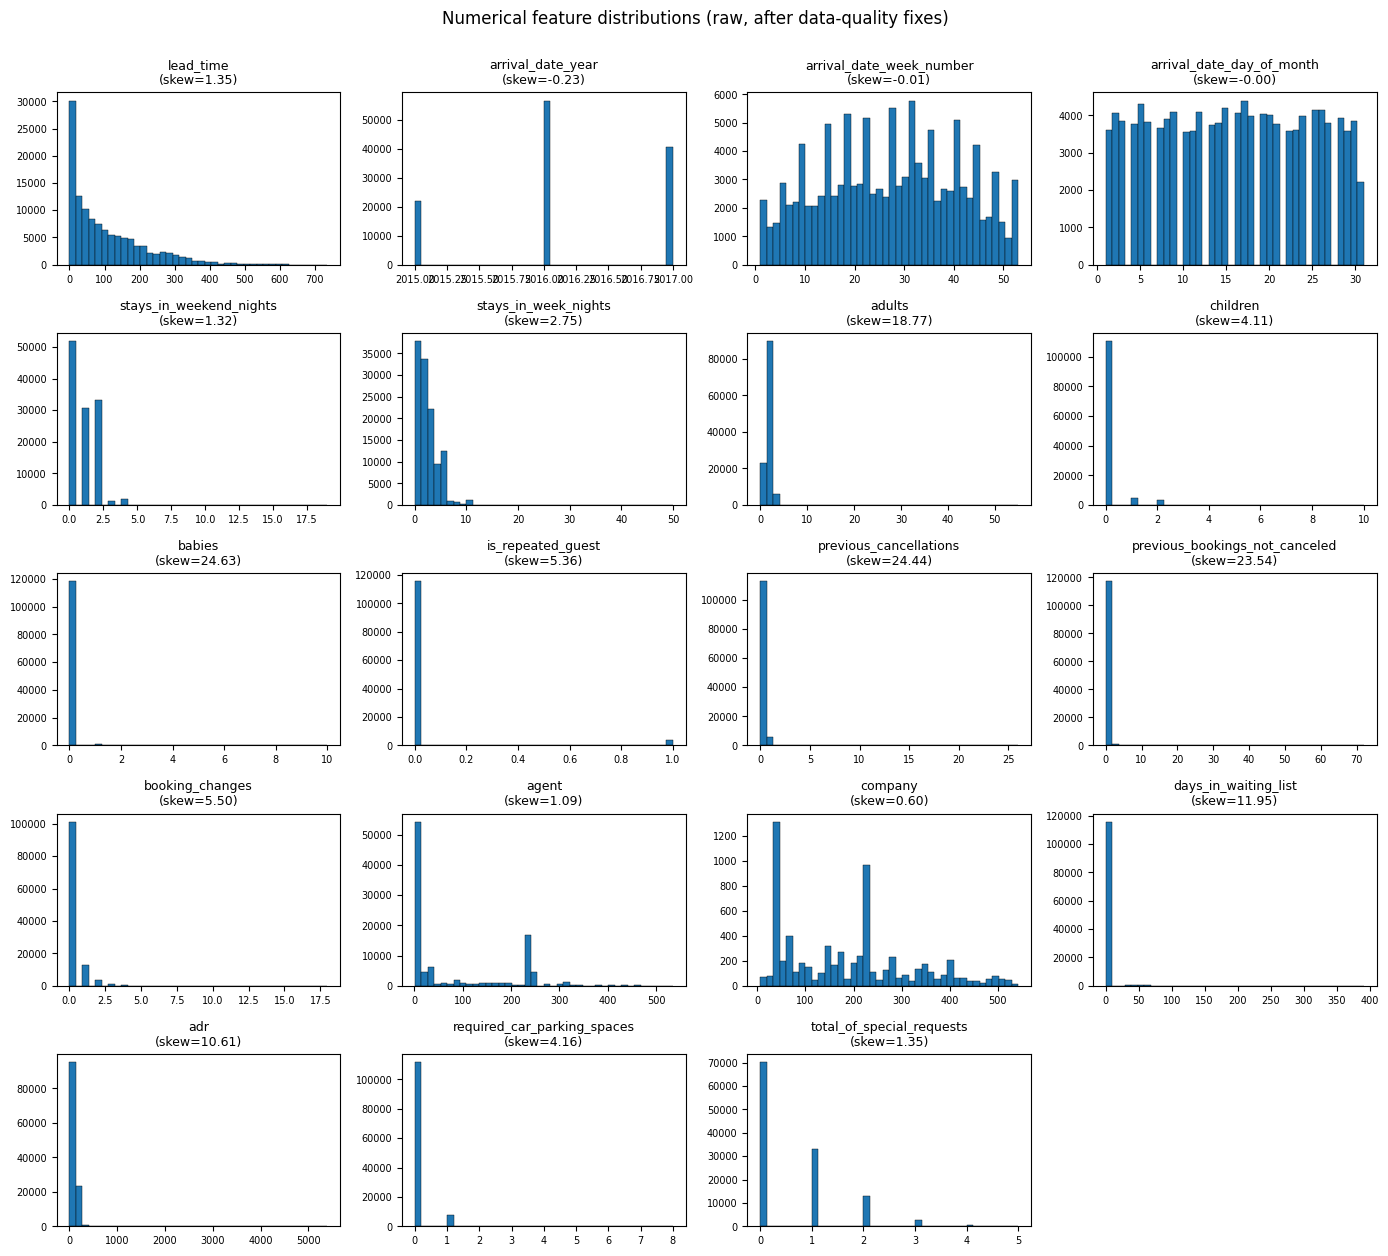


Features with |skew| > 2 (candidates for log-transform / robust scaling):
babies                            24.627962
previous_cancellations            24.443924
previous_bookings_not_canceled    23.539555
adults                            18.774333
days_in_waiting_list              11.948868
adr                               10.613328
booking_changes                    5.500058
is_repeated_guest                  5.364723
required_car_parking_spaces        4.162345
children                           4.109048
stays_in_week_nights               2.754863


In [51]:
num_cols_eda = df.select_dtypes(include=[np.number]).columns.tolist()
n = len(num_cols_eda)
ncols, nrows = 4, math.ceil(n / 4)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.5))
axes = axes.flatten()
for ax, col in zip(axes, num_cols_eda):
    s = df[col].dropna()
    ax.hist(s, bins=40, edgecolor='black', linewidth=0.3)
    ax.set_title(f'{col}\n(skew={s.skew():.2f})', fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes[n:]:
    ax.set_visible(False)
plt.suptitle('Numerical feature distributions (raw, after data-quality fixes)', y=1.001)
plt.tight_layout()
plt.show()

print('\nFeatures with |skew| > 2 (candidates for log-transform / robust scaling):')
skews = df[num_cols_eda].skew().abs().sort_values(ascending=False)
print(skews[skews > 2].to_string())

## Task 1.1.3.5 — Univariate distributions: categorical features

Cardinality audit. Long-tail features (especially `country`) motivate the rare-category rollup at the 1% threshold (Guidance slide 11 — *"group rare levels into Other"*).

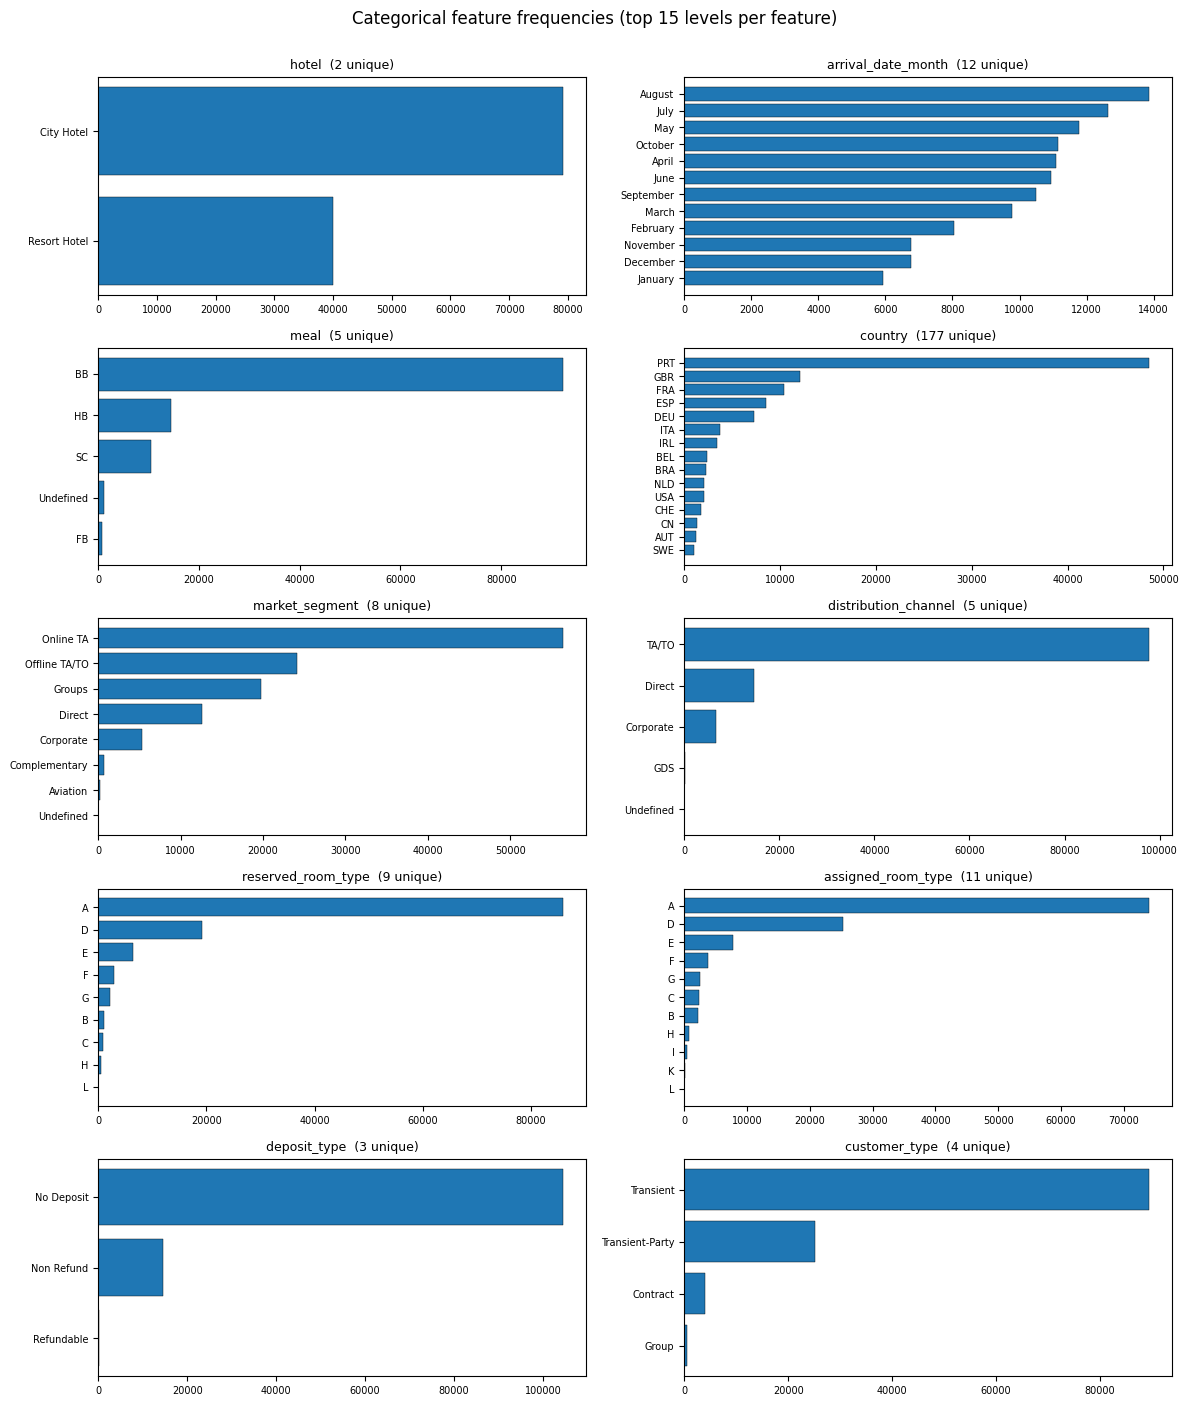


Cardinality summary:
             feature  n_unique        top  top_pct
               hotel         2 City Hotel     66.4
  arrival_date_month        12     August     11.6
                meal         5         BB     77.4
             country       178        PRT     40.7
      market_segment         8  Online TA     47.3
distribution_channel         5      TA/TO     82.0
  reserved_room_type         9          A     72.0
  assigned_room_type        11          A     62.1
        deposit_type         3 No Deposit     87.6
       customer_type         4  Transient     75.1

Rare-category rollup preview (threshold = 1%):
  hotel                             0 rare levels  (0.0% of rows)
  arrival_date_month                0 rare levels  (0.0% of rows)
  meal                              2 rare levels  (1.7% of rows)
  country                         163 rare levels  (9.9% of rows)
  market_segment                    3 rare levels  (0.8% of rows)
  distribution_channel              2 r

In [52]:
cat_cols_eda = df.select_dtypes(exclude=[np.number]).columns.tolist()
n = len(cat_cols_eda)
ncols, nrows = 2, math.ceil(n / 2)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 2.8))
axes = axes.flatten() if n > 1 else [axes]

cardinality_report = []
for ax, col in zip(axes, cat_cols_eda):
    vc = df[col].value_counts(dropna=False)
    cardinality_report.append({
        'feature': col,
        'n_unique': int(df[col].nunique(dropna=False)),
        'top': vc.index[0],
        'top_pct': round(vc.iloc[0] / len(df) * 100, 1),
    })
    top = vc.head(15)
    ax.barh(range(len(top)), top.values, edgecolor='black', linewidth=0.3)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=7)
    ax.invert_yaxis()
    ax.set_title(f'{col}  ({df[col].nunique()} unique)', fontsize=9)
    ax.tick_params(axis='x', labelsize=7)
for ax in axes[n:]:
    ax.set_visible(False)
plt.suptitle('Categorical feature frequencies (top 15 levels per feature)', y=1.001)
plt.tight_layout()
plt.show()

print('\nCardinality summary:')
print(pd.DataFrame(cardinality_report).to_string(index=False))

print('\nRare-category rollup preview (threshold = 1%):')
for col in cat_cols_eda:
    freq = df[col].value_counts(normalize=True)
    n_rare = int((freq < 0.01).sum())
    pct_rare_mass = float(freq[freq < 0.01].sum() * 100)
    print(f'  {col:<30s}  {n_rare:3d} rare levels  ({pct_rare_mass:.1f}% of rows)')

## Task 1.1.3.6 — Pairwise associations: Pearson + Cramér's V

Redundancy detection. Strong categorical associations (Cramér's V > 0.5) directly motivate the *drop-redundant-categoricals* sensitivity variant in §6 — e.g. `market_segment` ↔ `distribution_channel` are largely overlapping booking-channel labels.

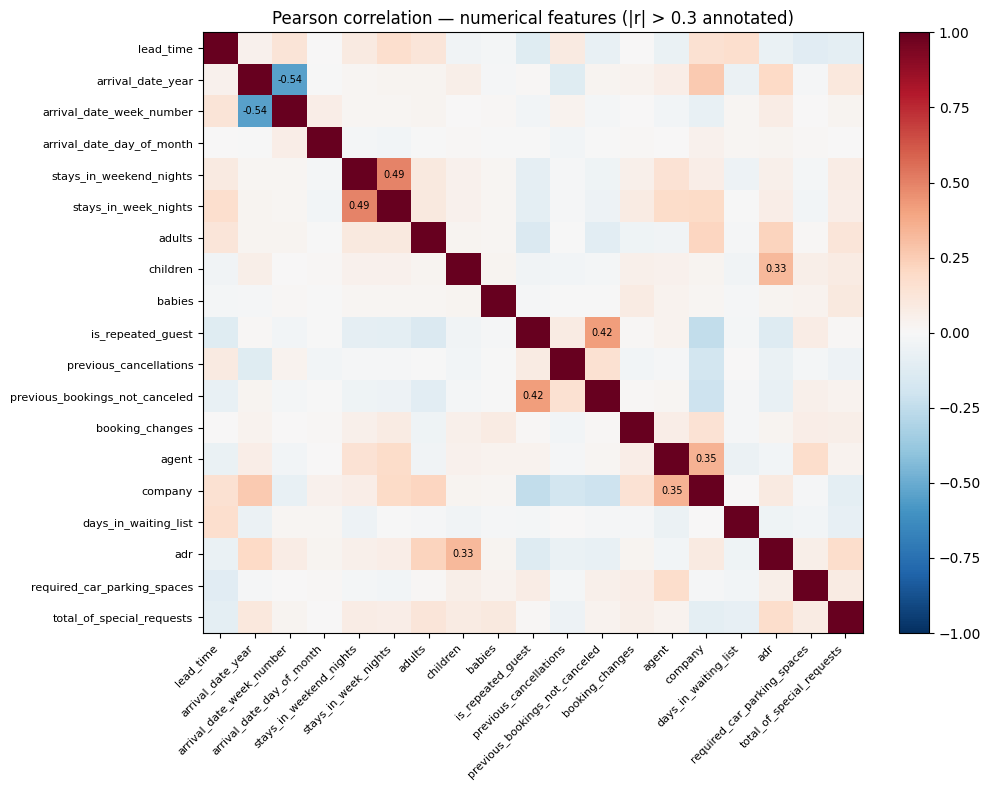

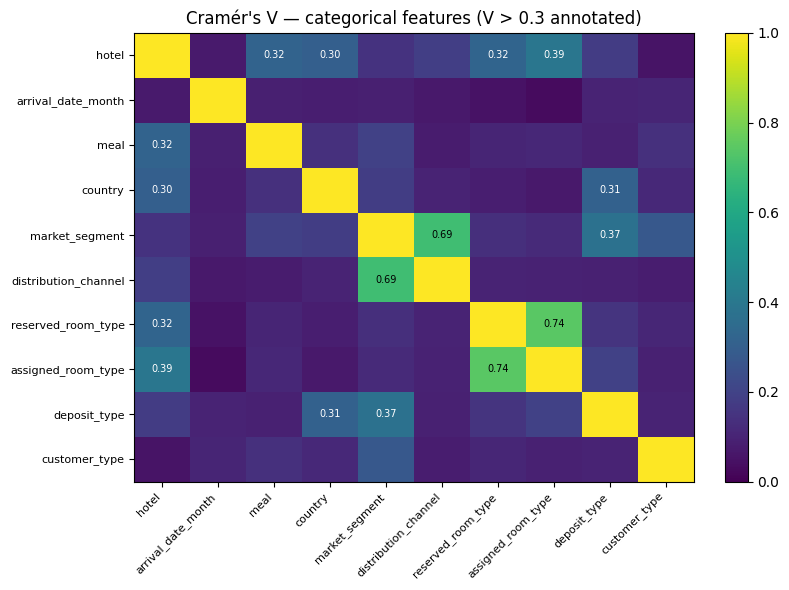


Top categorical associations (V > 0.3):
            feat_a               feat_b  cramers_v
reserved_room_type   assigned_room_type   0.744132
    market_segment distribution_channel   0.692129
             hotel   assigned_room_type   0.390837
    market_segment         deposit_type   0.374127
             hotel   reserved_room_type   0.323125
             hotel                 meal   0.316564
           country         deposit_type   0.312249
             hotel              country   0.301370


In [53]:
# Pearson correlation between numerical features
num_cols_eda = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols_eda].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(num_cols_eda)))
ax.set_yticks(range(len(num_cols_eda)))
ax.set_xticklabels(num_cols_eda, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(num_cols_eda, fontsize=8)
for i in range(len(num_cols_eda)):
    for j in range(len(num_cols_eda)):
        r = corr.iloc[i, j]
        if abs(r) > 0.3 and i != j:
            ax.text(j, i, f'{r:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(r) > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Pearson correlation — numerical features (|r| > 0.3 annotated)')
plt.tight_layout()
plt.show()


# Cramér's V (bias-corrected, Bergsma 2013) between categorical features
def cramers_v(x, y):
    cm = pd.crosstab(x, y).values
    chi2 = contingency.chi2_contingency(cm, correction=False)[0]
    n = cm.sum()
    r, k = cm.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (r - 1) * (k - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(r_corr - 1, k_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0


cat_cols_eda = df.select_dtypes(exclude=[np.number]).columns.tolist()
v_matrix = pd.DataFrame(np.zeros((len(cat_cols_eda), len(cat_cols_eda))),
                        index=cat_cols_eda, columns=cat_cols_eda)
for a in cat_cols_eda:
    for b in cat_cols_eda:
        v_matrix.loc[a, b] = cramers_v(df[a], df[b]) if a != b else 1.0

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(v_matrix, cmap='viridis', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(cat_cols_eda)))
ax.set_yticks(range(len(cat_cols_eda)))
ax.set_xticklabels(cat_cols_eda, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cat_cols_eda, fontsize=8)
for i in range(len(cat_cols_eda)):
    for j in range(len(cat_cols_eda)):
        v = v_matrix.iloc[i, j]
        if i != j and v > 0.3:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if v < 0.5 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Cramér's V — categorical features (V > 0.3 annotated)")
plt.tight_layout()
plt.show()

v_pairs = (v_matrix.where(np.triu(np.ones(v_matrix.shape), k=1).astype(bool))
                   .stack().reset_index())
v_pairs.columns = ['feat_a', 'feat_b', 'cramers_v']
print('\nTop categorical associations (V > 0.3):')
print(v_pairs[v_pairs['cramers_v'] > 0.3]
      .sort_values('cramers_v', ascending=False)
      .to_string(index=False))

## Task 1.1.3.7 — Hotel split (City vs Resort) — Cohen's *d*

The dataset contains two distinct hotels with very different operating profiles. Joint clustering risks rediscovering the hotel split as the dominant partition, which would be uninformative for RQ1 (travel-purpose segmentation rather than venue segmentation).

Cohen's *d* is the right diagnostic here because k-means minimises squared Euclidean distance in the standardised space — *d* is the per-feature signal-to-noise ratio in exactly that space. A feature with |*d*| > 0.8 between City and Resort has enough signal alone to make the hotel split dominate the partition.

| \|*d*\| | Magnitude |
|---|---|
| < 0.2 | negligible |
| 0.2 – 0.5 | small |
| 0.5 – 0.8 | medium |
| > 0.8 | large |
| > 1.2 | very large |

*Caveat:* *d* assumes approximately normal distributions and comparable variances. Several features (`lead_time`, `adr`) are right-skewed, so we treat *d* as an effect-size estimate rather than an exact value.

Hotel breakdown:
hotel
City Hotel      79163
Resort Hotel    40047
Name: count, dtype: int64



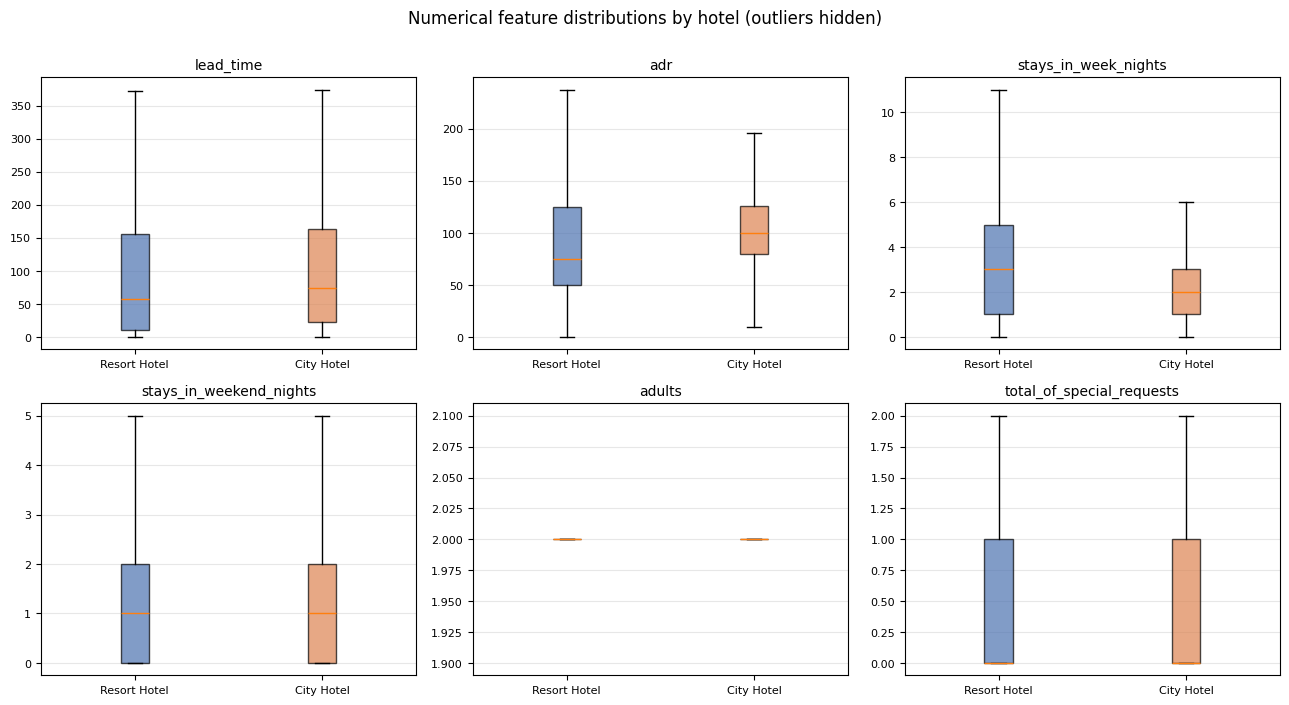

Median values by hotel + Cohen's d:
                  feature  median_City  median_Resort  cohens_d
                lead_time        74.00           57.0      0.16
                      adr        99.96           75.0      0.20
     stays_in_week_nights         2.00            3.0     -0.47
  stays_in_weekend_nights         1.00            1.0     -0.39
                   adults         2.00            2.0     -0.02
total_of_special_requests         0.00            0.0     -0.09

(|d| > 0.5 = medium; |d| > 0.8 = large — hotel split likely dominates clustering on those features.)

Market-segment share (%) by hotel:
hotel           City Hotel  Resort Hotel
market_segment                          
Aviation               0.3           0.0
Complementary          0.7           0.5
Corporate              3.8           5.8
Direct                 7.7          16.3
Groups                17.6          14.6
Offline TA/TO         21.1          18.7
Online TA             48.9          44.3
Undefined

In [54]:
hotel_col = 'hotel'
print(f'Hotel breakdown:\n{df[hotel_col].value_counts()}\n')

compare_features = ['lead_time', 'adr', 'stays_in_week_nights',
                    'stays_in_weekend_nights', 'adults', 'total_of_special_requests']
compare_features = [c for c in compare_features if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for ax, col in zip(axes, compare_features):
    data_by_hotel = [df.loc[df[hotel_col] == h, col].dropna() for h in df[hotel_col].unique()]
    bp = ax.boxplot(data_by_hotel, labels=df[hotel_col].unique(), showfliers=False, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Numerical feature distributions by hotel (outliers hidden)', y=1.001)
plt.tight_layout()
plt.show()

print("Median values by hotel + Cohen's d:")
rows = []
for col in compare_features:
    g1 = df.loc[df[hotel_col] == 'City Hotel',   col].dropna()
    g2 = df.loc[df[hotel_col] == 'Resort Hotel', col].dropna()
    pooled_std = np.sqrt(((g1.std() ** 2) + (g2.std() ** 2)) / 2)
    d = (g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else 0.0
    rows.append({
        'feature': col,
        'median_City':   round(g1.median(), 2),
        'median_Resort': round(g2.median(), 2),
        'cohens_d': round(d, 2),
    })
print(pd.DataFrame(rows).to_string(index=False))
print('\n(|d| > 0.5 = medium; |d| > 0.8 = large — hotel split likely dominates clustering on those features.)')

print('\nMarket-segment share (%) by hotel:')
ms_share = (pd.crosstab(df['market_segment'], df[hotel_col], normalize='columns') * 100).round(1)
print(ms_share.to_string())

## Task 1.1.3.8 — Seasonality and temporal patterns

RQ1 explicitly mentions seasonality. This panel checks whether monthly patterns differ by hotel and whether `lead_time` varies cyclically with month — a classic leisure vs business signal (leisure: longer lead times for peak months; business: shorter, more stable lead times).

This is also the motivation for the *cyclic month encoding* variant in §6: a flat OHE treats December ↔ January as fully independent, which is wrong if seasonality is cyclic.

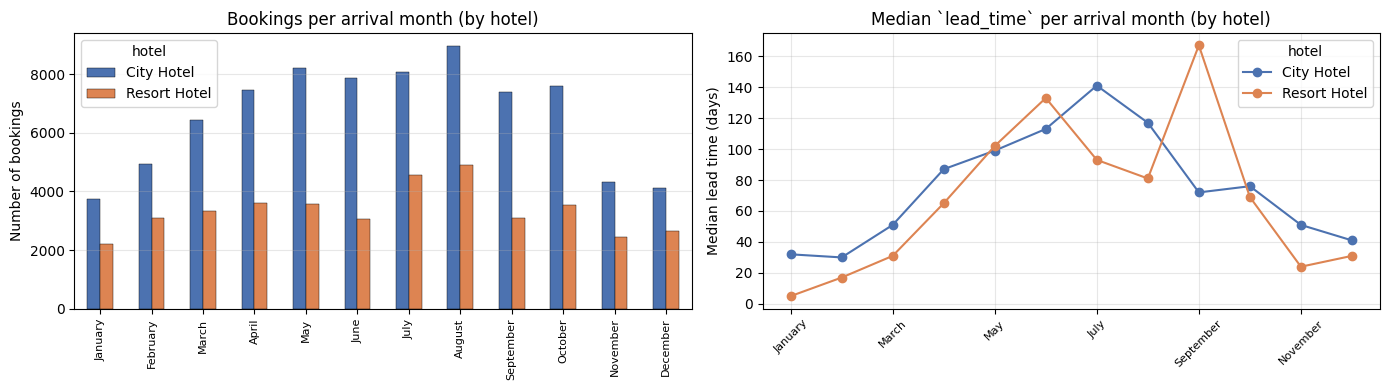

Seasonality summary — monthly coefficient of variation per hotel:
       hotel  cv_volume  cv_adr  cv_leadtime peak_month_volume peak_month_adr
Resort Hotel      0.238   0.543        0.730            August         August
  City Hotel      0.277   0.146        0.478            August            May

(Higher CV = stronger seasonality.)


In [55]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df_eda = df.copy()
df_eda['arrival_date_month'] = pd.Categorical(
    df_eda['arrival_date_month'], categories=month_order, ordered=True,
)

# Panel 1: Bookings per month, by hotel
month_by_hotel = pd.crosstab(df_eda['arrival_date_month'], df_eda['hotel'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
month_by_hotel.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'],
                    edgecolor='black', linewidth=0.3)
axes[0].set_title('Bookings per arrival month (by hotel)')
axes[0].set_ylabel('Number of bookings')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', labelsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: Median lead_time per month, by hotel
lead_by_month = (df_eda.groupby(['arrival_date_month', 'hotel'], observed=False)['lead_time']
                       .median().unstack())
lead_by_month.plot(ax=axes[1], marker='o', color=['#4C72B0', '#DD8452'])
axes[1].set_title('Median `lead_time` per arrival month (by hotel)')
axes[1].set_ylabel('Median lead time (days)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Seasonality summary — monthly coefficient of variation per hotel:')
rows = []
for hotel in df_eda['hotel'].unique():
    sub = df_eda[df_eda['hotel'] == hotel]
    monthly_counts = sub['arrival_date_month'].value_counts()
    monthly_adr   = sub.groupby('arrival_date_month', observed=False)['adr'].median()
    monthly_lead  = sub.groupby('arrival_date_month', observed=False)['lead_time'].median()
    rows.append({
        'hotel': hotel,
        'cv_volume':   round(monthly_counts.std() / monthly_counts.mean(), 3),
        'cv_adr':      round(monthly_adr.std() / monthly_adr.mean(), 3),
        'cv_leadtime': round(monthly_lead.std() / monthly_lead.mean(), 3),
        'peak_month_volume': monthly_counts.idxmax(),
        'peak_month_adr':    monthly_adr.idxmax(),
    })
print(pd.DataFrame(rows).to_string(index=False))
print('\n(Higher CV = stronger seasonality.)')

## Task 1.1.3.9 — Outlier visualisation in the standardised space

The IQR table (§3.3) lists outlier *counts*. This panel visualises their *position* after z-score scaling — points with |z| > 3 dominate Euclidean distance because their contribution to d² scales as z². This directly motivates the StandardScaler vs RobustScaler comparison in §6 (Guidance slide 19 — *"RobustScaler when outliers or heavy tails influence distances"*).

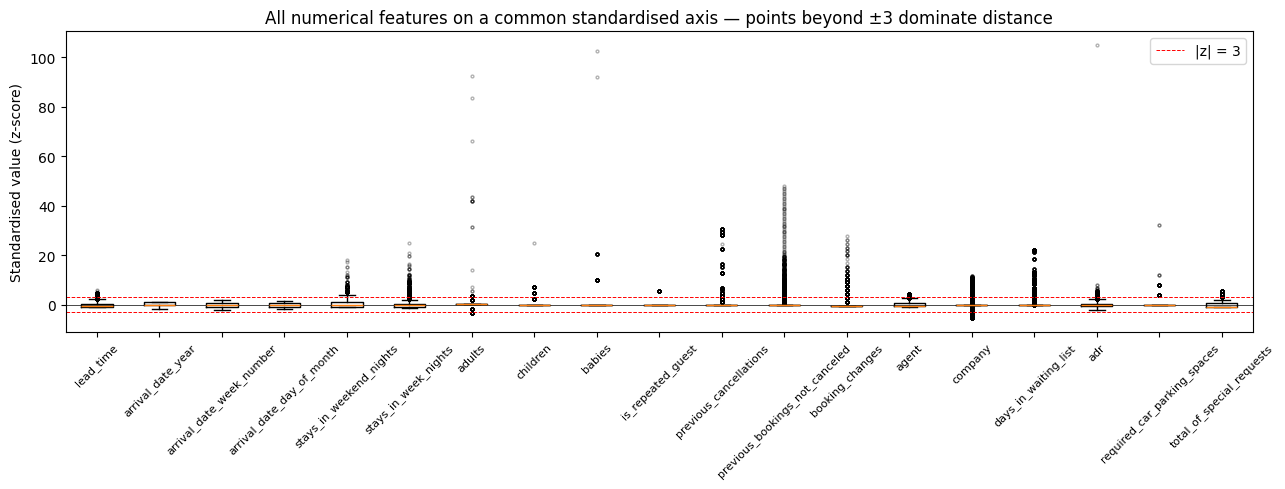

Extreme observations per feature in the standardised space:
                       feature  n_z>3  pct_z>3  n_z>5  max_abs_z
                           adr   1140     0.96     43     105.05
                        babies    917     0.77    917     102.47
                        adults    301     0.25     16      92.39
previous_bookings_not_canceled    933     0.78    551      47.97
   required_car_parking_spaces   7409     6.22     33      32.35
        previous_cancellations    317     0.27    221      30.67
               booking_changes   1532     1.29    618      27.85
          stays_in_week_nights   1652     1.39    339      25.04
                      children   3729     3.13     77      24.81
          days_in_waiting_list   1867     1.57    965      22.09
       stays_in_weekend_nights   2182     1.83    258      18.16
                       company   3778     3.17   1248      11.58
                     lead_time   1453     1.22      2       5.92
     total_of_special_requests

In [56]:
num_cols_eda = df.select_dtypes(include=[np.number]).columns.tolist()

# Preview z-scoring (used here for diagnostic only — the real scaling
# happens inside the §4 ColumnTransformer)
scaler_preview = StandardScaler()
X_num_scaled = scaler_preview.fit_transform(df[num_cols_eda].fillna(df[num_cols_eda].median()))
X_num_scaled_df = pd.DataFrame(X_num_scaled, columns=num_cols_eda)

fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot([X_num_scaled_df[c] for c in num_cols_eda], labels=num_cols_eda, showfliers=True,
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(3, color='red', linestyle='--', linewidth=0.7, label='|z| = 3')
ax.axhline(-3, color='red', linestyle='--', linewidth=0.7)
ax.set_ylabel('Standardised value (z-score)')
ax.set_title('All numerical features on a common standardised axis — points beyond ±3 dominate distance')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.legend()
plt.tight_layout()
plt.show()

print('Extreme observations per feature in the standardised space:')
extreme_rows = []
for col in num_cols_eda:
    z = X_num_scaled_df[col].abs()
    extreme_rows.append({
        'feature': col,
        'n_z>3': int((z > 3).sum()),
        'pct_z>3': round((z > 3).mean() * 100, 2),
        'n_z>5': int((z > 5).sum()),
        'max_abs_z': round(z.max(), 2),
    })
print(pd.DataFrame(extreme_rows).sort_values('max_abs_z', ascending=False).to_string(index=False))

---

# Task 1.1.4 — Main representation (RQ2)

> **Template §4 — required content:** included variables, excluded / profiling-only variables, numerical preprocessing (imputation, transforms, scaling), categorical preprocessing (rare-category rule, encoding, unknown-category handling), and the final `representation_id`.

This section turns the §3 findings into the actual feature matrix the clustering algorithm will see.

### Feature-selection table

The table below names every variable, its role, and the transformation applied. The *ordinal-policy* column addresses Guidance slides 12–18 — explicitly stating which variables are nominal, ordinal, or numerical, and the encoding choice for each.

| Feature | Type | Role | Ordinal policy | Transformation |
|---|---|---|---|---|
| `lead_time` | num | input | numerical (interval) | **log1p** → StandardScaler (skew = 1.35; Guidance slide 19) |
| `arrival_date_year` | num | input | numerical (3 values; treat as discrete numerical) | StandardScaler |
| `arrival_date_week_number` | num | input | **cyclic** (variant in §6) | StandardScaler (baseline); sin/cos in variant |
| `arrival_date_day_of_month` | num | input | **cyclic** (variant in §6) | StandardScaler (baseline); sin/cos in variant |
| `stays_in_weekend_nights` | num | input | numerical (count) | StandardScaler |
| `stays_in_week_nights` | num | input | numerical (count) | StandardScaler |
| `adults`, `children`, `babies` | num | input | numerical (count) | StandardScaler |
| `is_repeated_guest` | num | input | binary 0/1 — kept as-is | none |
| `previous_cancellations` | num | input | numerical (count) | **log1p** → StandardScaler (skew > 2) |
| `previous_bookings_not_canceled` | num | input | numerical (count) | **log1p** → StandardScaler (skew > 2) |
| `adr` | num | input | numerical (price) | StandardScaler; **§6 variant: RobustScaler + noADR comparison** |
| `required_car_parking_spaces` | num | input | numerical (count) | StandardScaler |
| `total_of_special_requests` | num | input | numerical (count) | StandardScaler |
| `hotel` | cat | input | nominal (2 levels) | OneHotEncoder |
| `arrival_date_month` | cat | input | **cyclic** (variant in §6) | OneHotEncoder (baseline); sin/cos in variant |
| `meal` | cat | input | nominal | OneHotEncoder + rare→Other |
| `country` | cat | input | nominal (high cardinality) | rare→Other (threshold 1%) → OneHotEncoder |
| `market_segment` | cat | input | nominal | OneHotEncoder + rare→Other |
| `distribution_channel` | cat | input | nominal | OneHotEncoder + rare→Other |
| `reserved_room_type` | cat | input | nominal (alphabetic codes; **not** ordinal — Guidance slide 14) | OneHotEncoder + rare→Other |
| `deposit_type` | cat | input | nominal | OneHotEncoder |
| `customer_type` | cat | input | nominal | OneHotEncoder |
| `is_canceled` | num | **profiling only** | — | not seen by clusterer |
| `reservation_status` | cat | **profiling only** | — | not seen by clusterer |
| `reservation_status_date` | datetime | **profiling only** | — | not seen by clusterer |
| `agent`, `company` | num | **excluded** | — | ID-like (§3.4) |
| `assigned_room_type`, `days_in_waiting_list`, `booking_changes` | mixed | **excluded** | — | post-booking (§3.4) |

### Variables retained for profiling only

The three outcome fields (`is_canceled`, `reservation_status`, `reservation_status_date`) are held in `df_labels` and used **only after** clusters are formed, to:

- compute per-cluster cancellation rate;
- describe each cluster's outcome composition in the §5.8 first profile note and the final-report cluster narrative;
- check whether the discovered profiles correlate with real outcomes (post-hoc validation).

They are never inputs to the algorithm.

### Numerical preprocessing — `log1p` + StandardScaler

Three changes from the original `main.ipynb` baseline, all motivated by Guidance slide 19 and the §3.5 skew findings:

1. **`log1p` transform on skewed counts.** `lead_time`, `previous_cancellations`, `previous_bookings_not_canceled` are non-negative with |skew| > 2. Raw z-scoring leaves the tail dominating Euclidean distance; `log1p` compresses the tail while keeping 0 at 0.
2. **Median imputation.** Unchanged from the original (robust to skew).
3. **StandardScaler.** Unchanged from the original. RobustScaler is the §6 sensitivity variant.

### Categorical preprocessing — rare-category rollup + full one-hot

Three changes / clarifications:

1. **Rare-category rollup at the 1% threshold.** Levels with frequency < 1% are recoded as `"Other"` before encoding (Guidance slide 11).
2. **`country` policy.** Guidance slide 11 specifically calls out country: *"keep top 15 + Other"* or a minimum-frequency rule. The 1% threshold collapses country to ~12 + Other (verified in §3.7 cardinality preview).
3. **`OneHotEncoder(handle_unknown='ignore')`.** Unknown categories at inference map to all-zero, preventing the pipeline from breaking on unseen levels.

### The `representation_id` name

Following Guidance slide 27, the `representation_id` encodes what's varied:

`R-EUCLID-standard-countryRareRollup-withADR-logSkewed`

Meaning: Euclidean distance, StandardScaler numerical scaling, rare-category rollup (which yields a top-N-style country trim), ADR included as input, and log1p on the skewed counts. This name is the *baseline*; §6 variants change one suffix at a time.

### Metric sentence (required by Guidance slide 5)

> *"We used representation `R-EUCLID-standard-countryRareRollup-withADR-logSkewed`. Numerical variables were imputed by median; lead_time, previous_cancellations and previous_bookings_not_canceled were `log1p`-transformed; all numerical variables were then scaled with StandardScaler. Categorical variables were mode-imputed; levels with frequency < 1% were grouped into `Other`; all retained levels were full one-hot encoded with `handle_unknown='ignore'`. One-hot columns were not rescaled (they stay 0/1). ADR is included as a clustering input; a noADR variant in §6 quantifies its impact. All clustering and internal indices use Euclidean distance in this final encoded matrix."*

In [57]:
# Feature roles (§4.1 of the markdown above)
NUMERICAL = [
    'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month',
    'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies',
    'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled',
    'adr',
    'required_car_parking_spaces', 'total_of_special_requests',
]
CATEGORICAL = [
    'hotel', 'arrival_date_month', 'meal', 'country',
    'market_segment', 'distribution_channel',
    'reserved_room_type', 'deposit_type', 'customer_type',
]

# Skewed numerical variables → log1p before scaling (Guidance slide 19)
LOG_SKEWED = ['lead_time', 'previous_cancellations', 'previous_bookings_not_canceled']

# Sanity-check every column actually exists
missing_num = [c for c in NUMERICAL if c not in df_features.columns]
missing_cat = [c for c in CATEGORICAL if c not in df_features.columns]
assert not missing_num, f'Missing numerical: {missing_num}'
assert not missing_cat, f'Missing categorical: {missing_cat}'

print(f'Numerical features            : {len(NUMERICAL)}')
print(f'  of which log1p-transformed  : {len(LOG_SKEWED)} → {LOG_SKEWED}')
print(f'Categorical features          : {len(CATEGORICAL)}')

Numerical features            : 15
  of which log1p-transformed  : 3 → ['lead_time', 'previous_cancellations', 'previous_bookings_not_canceled']
Categorical features          : 9


## Task 1.1.4.1 — Rare-category rollup (executed before the pipeline)

We collapse rare levels into `"Other"` **before** the `ColumnTransformer` so the OHE step sees a stable set of categories. This is the implementation of the rule named in §4.4.

In [58]:
RARE_THRESHOLD = 0.01
rare_log = []
for col in CATEGORICAL:
    freq = df_features[col].value_counts(normalize=True)
    rare = freq[freq < RARE_THRESHOLD].index.tolist()
    if rare:
        df_features[col] = df_features[col].where(~df_features[col].isin(rare), other='Other')
        rare_log.append({
            'feature': col,
            'n_rare_levels': len(rare),
            'pct_rows_affected': round(100 * freq[rare].sum(), 2),
        })

if rare_log:
    print('Rare-category rollup (threshold = 1%):')
    print(pd.DataFrame(rare_log).to_string(index=False))
else:
    print('No categorical features had levels below the 1% threshold.')

Rare-category rollup (threshold = 1%):
             feature  n_rare_levels  pct_rows_affected
                meal              2               1.65
             country            163               9.87
      market_segment              3               0.81
distribution_channel              2               0.17
  reserved_room_type              4               2.23
        deposit_type              1               0.14
       customer_type              1               0.48


## Task 1.1.4.2 — ColumnTransformer pipeline

The pipeline below is the single source of truth for the main representation. Both `log1p` and `StandardScaler` are applied to the same numerical columns, but `log1p` is only applied to the skewed subset and the rest pass through scaling unchanged.

We build it as two parallel numerical branches (skewed → log1p → scale; rest → scale) plus the categorical branch.

In [59]:
# Skewed numerical branch: log1p → median impute → StandardScaler
# (impute AFTER log1p so the imputed value also lives in log space)
log_pipeline = Pipeline([
    ('log1p',  FunctionTransformer(np.log1p, validate=False)),
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

# Non-skewed numerical branch: median impute → StandardScaler
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

# Categorical branch: most_frequent → OneHotEncoder
cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

NUMERICAL_REST = [c for c in NUMERICAL if c not in LOG_SKEWED]

preprocessor = ColumnTransformer([
    ('num_log', log_pipeline,  LOG_SKEWED),
    ('num',     num_pipeline,  NUMERICAL_REST),
    ('cat',     cat_pipeline,  CATEGORICAL),
], remainder='drop')

X = preprocessor.fit_transform(df_features)

ohe_names = (preprocessor.named_transformers_['cat']
             .named_steps['encode']
             .get_feature_names_out(CATEGORICAL).tolist())
feature_names = LOG_SKEWED + NUMERICAL_REST + ohe_names
X_df = pd.DataFrame(X, columns=feature_names, index=df_features.index)

print(f'Final matrix shape    : {X_df.shape}')
print(f'  log1p+scaled dims   : {len(LOG_SKEWED)}')
print(f'  scaled-only dims    : {len(NUMERICAL_REST)}')
print(f'  OHE dims            : {len(ohe_names)}')
print(f'  Total samples       : {X_df.shape[0]:,}')
print(f'  NaN in output       : {int(X_df.isnull().sum().sum())}')

Final matrix shape    : (119210, 71)
  log1p+scaled dims   : 3
  scaled-only dims    : 12
  OHE dims            : 56
  Total samples       : 119,210
  NaN in output       : 0


## Task 1.1.4.3 — Distance contribution check (Guidance slide 27)

Before clustering, we sample random booking pairs and decompose the squared Euclidean distance by feature block. This is the *"can another team reconstruct exactly the matrix on which the algorithm computed distances?"* check from the guidance.

If one block dominates (>60% of average d²), the pipeline silently weights the clustering toward that family of features — a real risk after one-hot encoding inflates the categorical block.

In [60]:
BLOCKS = {
    'log_numerical': LOG_SKEWED,
    'rest_numerical': NUMERICAL_REST,
    'categorical_ohe': ohe_names,
}

rng = np.random.default_rng(17341)
sample_pairs = rng.choice(X_df.index, size=(2000, 2), replace=True)

block_contribs = {name: [] for name in BLOCKS}
for i, j in sample_pairs:
    if i == j:
        continue
    a, b = X_df.loc[i], X_df.loc[j]
    for name, cols in BLOCKS.items():
        block_contribs[name].append(float(((a[cols] - b[cols]) ** 2).sum()))

contrib_df = pd.DataFrame({
    'block': list(block_contribs.keys()),
    'n_features': [len(BLOCKS[k]) for k in block_contribs],
    'mean_sq_contrib': [round(np.mean(v), 3) for v in block_contribs.values()],
})
contrib_df['share_pct'] = (contrib_df['mean_sq_contrib'] /
                            contrib_df['mean_sq_contrib'].sum() * 100).round(1)
print('Average squared-distance contribution per feature block (2000 random pairs):')
print(contrib_df.to_string(index=False))
print('\n(If categorical_ohe > 60%, the OHE block dominates the distance and clusters '
      'will largely be partitions on the categorical variables. §6 variant: drop redundant '
      'categoricals to test this.)')

Average squared-distance contribution per feature block (2000 random pairs):
          block  n_features  mean_sq_contrib  share_pct
  log_numerical           3            5.540       14.8
 rest_numerical          12           22.607       60.5
categorical_ohe          56            9.227       24.7

(If categorical_ohe > 60%, the OHE block dominates the distance and clusters will largely be partitions on the categorical variables. §6 variant: drop redundant categoricals to test this.)


## Task 1.1.4.4 — Save the `representation_id` artefact

The JSON file at `artifacts/<representation_id>.json` is the persisted spec — every later experiment row in `experiments.csv` references it.

In [61]:
REPRESENTATION_ID = 'R-EUCLID-standard-countryRareRollup-withADR-logSkewed'

representation_spec = {
    'representation_id': REPRESENTATION_ID,
    'created_at': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'dataset_path': DATASET_PATH,
    'dataset_sha256': DATASET_SHA256,
    'n_rows': int(X_df.shape[0]),
    'n_features_total': int(X_df.shape[1]),
    'numerical_features_log1p': LOG_SKEWED,
    'numerical_features_scaled_only': NUMERICAL_REST,
    'categorical_features': CATEGORICAL,
    'excluded_leakage': PROFILING_LABELS,
    'excluded_post_booking': POST_BOOKING,
    'excluded_id_like': ID_LIKE,
    'numerical_imputation': 'median (after log1p where applicable)',
    'numerical_scaling': 'StandardScaler (z-score)',
    'numerical_transforms': f'log1p applied to {LOG_SKEWED}',
    'categorical_imputation': 'most_frequent',
    'categorical_encoding': "OneHotEncoder(handle_unknown='ignore', sparse_output=False)",
    'rare_category_threshold': RARE_THRESHOLD,
    'adr_in_inputs': True,
    'adr_sensitivity_planned': 'noADR variant in §6',
    'implied_metric': (
        'Euclidean distance on rows of the final encoded matrix '
        '(log1p+z-scored skewed numericals + z-scored numericals + 0/1 one-hot binaries). '
        'One-hot columns are not rescaled.'
    ),
}

artefact_path = f'artifacts/{REPRESENTATION_ID}.json'
with open(artefact_path, 'w') as f:
    json.dump(representation_spec, f, indent=2)
print(f'Saved representation spec → {artefact_path}')
print(f'representation_id = {REPRESENTATION_ID}')

Saved representation spec → artifacts/R-EUCLID-standard-countryRareRollup-withADR-logSkewed.json
representation_id = R-EUCLID-standard-countryRareRollup-withADR-logSkewed


## Task 1.1.4.5 — Worked example: two bookings decomposed

> **Guidance requirement:** *"students must explain one pair of bookings before interpreting clusters."*

We pick two real bookings from `X_df`, print their values on a handful of representative features, and show how each block contributes to the total squared distance. This is the artefact the guidance explicitly asks for.

In [62]:
# Pick two random bookings with different `market_segment` and `meal`
example_rng = np.random.default_rng(17341)
# Ensure this is a writable array before in-place shuffle.
candidates = df_features.index.to_numpy(copy=True)
example_rng.shuffle(candidates)

i_a, i_b = None, None
for idx in candidates[:1000]:
    if i_a is None:
        i_a = idx
        continue
    if (df_features.loc[idx, 'market_segment'] != df_features.loc[i_a, 'market_segment']
            and df_features.loc[idx, 'meal'] != df_features.loc[i_a, 'meal']):
        i_b = idx
        break

print('Booking A (index {}):'.format(i_a))
print(df_features.loc[i_a, ['lead_time', 'stays_in_week_nights', 'adr',
                            'meal', 'market_segment', 'reserved_room_type']].to_string())
print('\nBooking B (index {}):'.format(i_b))
print(df_features.loc[i_b, ['lead_time', 'stays_in_week_nights', 'adr',
                            'meal', 'market_segment', 'reserved_room_type']].to_string())

# Decompose d² by block
a, b = X_df.loc[i_a], X_df.loc[i_b]
rows = []
for name, cols in BLOCKS.items():
    contrib = float(((a[cols] - b[cols]) ** 2).sum())
    rows.append({'block': name, 'n_features': len(cols), 'contribution_to_d2': round(contrib, 3)})

contrib_table = pd.DataFrame(rows)
total = contrib_table['contribution_to_d2'].sum()
contrib_table['share_pct'] = (contrib_table['contribution_to_d2'] / total * 100).round(1)
print(f'\nd²(A, B) = {total:.3f}     d(A, B) = {np.sqrt(total):.3f}')
print('\nContribution decomposition:')
print(contrib_table.to_string(index=False))

Booking A (index 105254):
lead_time                       1
stays_in_week_nights            4
adr                         108.8
meal                           BB
market_segment          Online TA
reserved_room_type              A

Booking B (index 82924):
lead_time                         177
stays_in_week_nights                0
adr                             121.0
meal                               HB
market_segment          Offline TA/TO
reserved_room_type                  A

d²(A, B) = 55.809     d(A, B) = 7.471

Contribution decomposition:
          block  n_features  contribution_to_d2  share_pct
  log_numerical           3              19.722       35.3
 rest_numerical          12              26.087       46.7
categorical_ohe          56              10.000       17.9


---

# Experiment logging — schema and helper

> **Forward reference.** The experiment-logging infrastructure is part of **Brief §Task 4.2** ("maintain a machine-readable experiment log") but the code has to exist *before* the Task 1.2 fits can call it. The full §Task 4.2 framing is at the end of the notebook.

The schema is defined here; every fit in Task 1.2 and Task 2 logs through `log_experiment(...)`. The CSV is the single source of truth for results across the project.

### Schema

| Column | Type | Description |
|---|---|---|
| `run_id` | str | Short UUID per run |
| `timestamp` | str (ISO 8601) | UTC time the run started |
| `representation_id` | str | Links to `artifacts/<id>.json` |
| `method` | str | `kmeans`, `ikmeans`, `ward`, `gmm`, `dbscan` |
| `parameters` | str (JSON) | Algorithm-specific params |
| `seed` | int | Random seed (where applicable) |
| `k` | int | Number of clusters (NaN for DBSCAN) |
| `sample_rule` | str | How rows were selected |
| `n_train`, `n_val` | int | Rows used for fitting / validation |
| `silhouette_train/val` | float | Silhouette score (sampled to 5000) |
| `davies_bouldin_train/val` | float | Davies–Bouldin score |
| `calinski_harabasz_train/val` | float | Calinski–Harabasz score |
| `runtime_s` | float | Fit + predict time in seconds |
| `noise_pct` | float | DBSCAN only — % of points labelled noise |
| `notes` | str | Free-form |

In [63]:
EXPERIMENTS_PATH = 'experiments.csv'

EXPERIMENTS_COLUMNS = [
    'run_id', 'timestamp', 'representation_id', 'method', 'parameters',
    'seed', 'k', 'sample_rule', 'n_train', 'n_val',
    'silhouette_train', 'davies_bouldin_train', 'calinski_harabasz_train',
    'silhouette_val', 'davies_bouldin_val', 'calinski_harabasz_val',
    'runtime_s', 'noise_pct', 'notes',
]


def _normalize_experiment_row(row):
    """Map legacy/new row lengths to the current EXPERIMENTS_COLUMNS schema."""
    target_len = len(EXPERIMENTS_COLUMNS)

    # Legacy schema without noise_pct.
    if len(row) == target_len - 1:
        return row[:-1] + [''] + [row[-1]]

    # Perfect match.
    if len(row) == target_len:
        return row

    # Truncated row: pad with empties.
    if len(row) < target_len:
        return row + [''] * (target_len - len(row))

    # Overlong row: keep first columns and merge overflow into notes.
    merged_notes = ','.join(row[target_len - 1:])
    return row[:target_len - 1] + [merged_notes]


def repair_experiments_csv(path: str = EXPERIMENTS_PATH):
    """Rewrite experiments.csv so all rows conform to EXPERIMENTS_COLUMNS."""
    import csv

    if not os.path.exists(path):
        pd.DataFrame(columns=EXPERIMENTS_COLUMNS).to_csv(path, index=False)
        return 0

    with open(path, 'r', newline='', encoding='utf-8') as f:
        rows = list(csv.reader(f))

    if not rows:
        pd.DataFrame(columns=EXPERIMENTS_COLUMNS).to_csv(path, index=False)
        return 0

    header = rows[0]
    data_rows = rows[1:]

    changed = int(header != EXPERIMENTS_COLUMNS)
    fixed_rows = []
    for row in data_rows:
        fixed = _normalize_experiment_row(row)
        fixed_rows.append(fixed)
        if fixed != row:
            changed += 1

    if changed > 0:
        with open(path, 'w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(EXPERIMENTS_COLUMNS)
            writer.writerows(fixed_rows)

    return changed


def load_experiments(path: str = EXPERIMENTS_PATH) -> pd.DataFrame:
    """Load experiments.csv after enforcing the current schema."""
    n_fixed = repair_experiments_csv(path)
    if n_fixed > 0:
        print(f'Normalised {n_fixed} rows/header in {path} to current schema.')
    return pd.read_csv(path)


if not os.path.exists(EXPERIMENTS_PATH):
    pd.DataFrame(columns=EXPERIMENTS_COLUMNS).to_csv(EXPERIMENTS_PATH, index=False)
    print(f'Initialised empty {EXPERIMENTS_PATH}')
else:
    n_rows = len(load_experiments(EXPERIMENTS_PATH))
    print(f'{EXPERIMENTS_PATH} already exists with {n_rows} prior runs.')


def log_experiment(record: dict, path: str = EXPERIMENTS_PATH) -> str:
    'Append a single experiment record to experiments.csv. Returns run_id.'
    full = {col: record.get(col, None) for col in EXPERIMENTS_COLUMNS}
    if full['run_id'] is None:
        full['run_id'] = uuid.uuid4().hex[:8]
    if full['timestamp'] is None:
        full['timestamp'] = datetime.now(timezone.utc).isoformat(timespec='seconds')
    full['representation_id'] = full.get('representation_id') or REPRESENTATION_ID
    pd.DataFrame([full], columns=EXPERIMENTS_COLUMNS).to_csv(
        path, mode='a', header=False, index=False,
    )
    return full['run_id']

experiments.csv already exists with 360 prior runs.


---

# Task 1.2 — Learn a baseline clustering model

> **Brief §1.2:** *"Run k-means (or MiniBatch k-means) as the baseline method (mandatory). Select a small, justified range of k values; do not use unbounded searches. Provide an initial interpretation of the resulting clusters (cluster profiles). The chosen range of k must be justified, and the final selection rule must be explicitly stated. Include iK-means and evaluate it under the same protocol (runtime + validation metrics)."*

This is the **baseline study** required by Brief Task 1.2. Both k-means and iK-means are run over a 6-value k-grid × 10 seeds, with internal indices logged to `experiments.csv` (the logging schema is defined in §Task 4.2 below, executed earlier so this section can use it).

## Task 1.2.1 — K-grid choice and protocol

We evaluate **k ∈ {3, 4, 5, 6, 7, 8}** (Brief §1.2 — *"small, justified range; do not use unbounded searches"*).

Justification:

- *k < 3* is too coarse: the RQ presupposes at least a leisure/business split plus micro-segments (Spec §3).
- *k > 8* produces clusters that are too small to be operationally meaningful for hotel revenue management.
- The 3–8 range admits a leisure-vs-business split plus 1–6 micro-segments.

**Train / validation split — 80 / 20** with `random_state = 17341`. Ward in §Task 2 will subsample further; this split keeps k-means and iK-means tractable.

**Seeds — 10** (`range(17341, 17351)`) — satisfies Brief §3.3 *"minimum 10 runs where randomness applies"*.

In [64]:
KVALUES = list(range(3, 9))
SEEDS = list(range(17341, 17351))
SILHOUETTE_SAMPLE = 5000  # silhouette on full 95k train set is prohibitively slow

split_seed = SEEDS[0]
train_idx, val_idx = train_test_split(X_df.index, train_size=0.8, random_state=split_seed)
X_train = X_df.loc[train_idx]
X_val   = X_df.loc[val_idx]

print(f'X_train shape : {X_train.shape}')
print(f'X_val   shape : {X_val.shape}')
print(f'k-grid        : {KVALUES}')
print(f'seeds         : {SEEDS}')


def score_partition(X, labels, sample_size, seed):
    'Compute silhouette / Davies-Bouldin / Calinski-Harabasz. Silhouette is sampled.'
    s  = silhouette_score(X, labels, sample_size=sample_size, random_state=seed)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    return s, db, ch

X_train shape : (95368, 71)
X_val   shape : (23842, 71)
k-grid        : [3, 4, 5, 6, 7, 8]
seeds         : [17341, 17342, 17343, 17344, 17345, 17346, 17347, 17348, 17349, 17350]


## Task 1.2.2 — K-means baseline (k-means++ init)

Note: this is a **rewrite** of the original `main.ipynb` k-means cell. The original logged three rows per fit (one per metric) and used `.groupby().max()` to merge them — fragile. Here each fit logs a single dict with all three metrics.

We cache the train labels in `kmeans_labels[(k, seed)]` for the §6.5 ARI stability computation.

In [65]:
kmeans_labels = {}
kmeans_runids = {}

for k in KVALUES:
    for seed in SEEDS:
        t0 = time.time()
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=seed)
        labels_train = km.fit_predict(X_train)
        labels_val   = km.predict(X_val)
        runtime_s = time.time() - t0

        s_t, db_t, ch_t = score_partition(X_train, labels_train, SILHOUETTE_SAMPLE, seed)
        s_v, db_v, ch_v = score_partition(X_val,   labels_val,   SILHOUETTE_SAMPLE, seed)

        run_id = log_experiment({
            'method': 'kmeans',
            'parameters': json.dumps({'init': 'k-means++', 'n_init': 10}),
            'seed': seed, 'k': k,
            'sample_rule': f'train_80pct_seed={split_seed}',
            'n_train': int(len(X_train)), 'n_val': int(len(X_val)),
            'silhouette_train': round(s_t, 4),
            'davies_bouldin_train': round(db_t, 4),
            'calinski_harabasz_train': round(ch_t, 2),
            'silhouette_val': round(s_v, 4),
            'davies_bouldin_val': round(db_v, 4),
            'calinski_harabasz_val': round(ch_v, 2),
            'runtime_s': round(runtime_s, 3),
            'notes': '',
        })
        kmeans_labels[(k, seed)] = labels_train
        kmeans_runids[(k, seed)] = run_id

    print(f'k={k} done.')

print(f'\nLogged {len(kmeans_runids)} k-means runs to {EXPERIMENTS_PATH}.')

k=3 done.
k=4 done.
k=5 done.
k=6 done.
k=7 done.
k=8 done.

Logged 60 k-means runs to experiments.csv.


## Task 1.2.3 — iK-means baseline (anomalous-pattern initialisation)

> **Brief Task 1.2 requirement:** *"Include iK-means and evaluate it under the same protocol (runtime + validation metrics)."*

iK-means runs the Mirkin anomalous-pattern (AP) procedure to extract clusters one by one and uses their standardised centroids as initial seeds for a final k-means refinement.

Two important properties:

1. **`k` is chosen by the algorithm**, not specified up front. To produce a result for each k in our grid, we run AP once on the train set and then take the top-k retained centroids (by `scatter_pct`) as initialisation for k-means with that `n_clusters`.
2. **AP is deterministic given the input.** Seed-based variability comes from the downstream k-means refinement.

Implementation follows `ikmeans.py` (Mirkin 2005; Chiang & Mirkin 2010).

In [66]:
# AP extraction is deterministic; run it once on the full X_train
MIN_CLUSTER_SIZE = max(50, int(0.005 * len(X_train)))  # 0.5% of train rows or 50
print(f'iK-means min_cluster_size = {MIN_CLUSTER_SIZE} (0.5% of {len(X_train)})')

t_ap_0 = time.time()
ap_clusters, init_centroids = ikmeans_initialize(
    X_train.values,
    min_cluster_size=MIN_CLUSTER_SIZE,
    tol=1e-12,
    max_iter=10_000,
)
t_ap = time.time() - t_ap_0

# Sort retained AP clusters by scatter_pct (most informative first)
ap_retained = sorted(
    [c for c in ap_clusters if c.size >= MIN_CLUSTER_SIZE],
    key=lambda c: c.scatter_pct, reverse=True,
)
n_retained = len(ap_retained)

print(f'\nAP extraction: {len(ap_clusters)} total clusters, {n_retained} retained '
      f'(size >= {MIN_CLUSTER_SIZE})')
print(f'AP runtime: {t_ap:.2f}s')
print('\nTop retained AP clusters:')
for i, c in enumerate(ap_retained[:10]):
    print(f'  #{i}: size={c.size:6d}, scatter_pct={c.scatter_pct:6.2f}%')

iK-means min_cluster_size = 476 (0.5% of 95368)

AP extraction: 18 total clusters, 8 retained (size >= 476)
AP runtime: 2.95s

Top retained AP clusters:
  #0: size= 32048, scatter_pct=  6.53%
  #1: size=  8707, scatter_pct=  5.40%
  #2: size= 12385, scatter_pct=  4.95%
  #3: size=  9123, scatter_pct=  4.04%
  #4: size=  9926, scatter_pct=  3.63%
  #5: size=  8077, scatter_pct=  3.30%
  #6: size= 11712, scatter_pct=  2.46%
  #7: size=  3125, scatter_pct=  0.96%


In [67]:
# Standardise X_train / X_val using the same mean/range that ikmeans_initialize used
g_mean, feature_scale, _ = compute_feature_statistics(X_train.values)
X_train_std = (X_train.values - g_mean) / feature_scale
X_val_std   = (X_val.values   - g_mean) / feature_scale

ikmeans_labels = {}
ikmeans_runids = {}

for k in KVALUES:
    if k > n_retained:
        print(f'k={k}: skipped (only {n_retained} AP clusters retained).')
        continue
    init_k = init_centroids[:k]  # top-k by scatter_pct, in standardised space

    for seed in SEEDS:
        t0 = time.time()
        km = KMeans(n_clusters=k, init=init_k, n_init=1, random_state=seed)
        labels_train = km.fit_predict(X_train_std)
        labels_val   = km.predict(X_val_std)
        runtime_s = (time.time() - t0) + (t_ap if seed == SEEDS[0] else 0.0)

        s_t, db_t, ch_t = score_partition(X_train_std, labels_train, SILHOUETTE_SAMPLE, seed)
        s_v, db_v, ch_v = score_partition(X_val_std,   labels_val,   SILHOUETTE_SAMPLE, seed)

        run_id = log_experiment({
            'method': 'ikmeans',
            'parameters': json.dumps({
                'min_cluster_size': MIN_CLUSTER_SIZE,
                'n_init': 1,
                'init_source': 'AP_top_k_by_scatter_pct',
                'n_ap_retained': n_retained,
            }),
            'seed': seed, 'k': k,
            'sample_rule': f'train_80pct_seed={split_seed}',
            'n_train': int(len(X_train_std)), 'n_val': int(len(X_val_std)),
            'silhouette_train': round(s_t, 4),
            'davies_bouldin_train': round(db_t, 4),
            'calinski_harabasz_train': round(ch_t, 2),
            'silhouette_val': round(s_v, 4),
            'davies_bouldin_val': round(db_v, 4),
            'calinski_harabasz_val': round(ch_v, 2),
            'runtime_s': round(runtime_s, 3),
            'notes': 'AP runtime recorded on first seed only',
        })
        ikmeans_labels[(k, seed)] = labels_train
        ikmeans_runids[(k, seed)] = run_id

print(f'\nLogged {len(ikmeans_runids)} iK-means runs to {EXPERIMENTS_PATH}.')


Logged 60 iK-means runs to experiments.csv.


## Task 1.2.4 — Internal-indices summary (mean ± std over seeds)

> **Brief Task 3.1:** *"Report Silhouette score and at least one additional internal index. All indices must be computed in the same representation and metric space."*

We aggregate from `experiments.csv` so this table is reproducible from the log alone.

In [68]:
exp_df = load_experiments(EXPERIMENTS_PATH)
exp_now = exp_df[exp_df['representation_id'] == REPRESENTATION_ID].copy()


def summarise_metric(frame, metric):
    return (frame.groupby(['method', 'k'])[metric]
                 .agg(['mean', 'std']).round(4)
                 .reset_index()
                 .pivot(index='k', columns='method'))


print('=== Silhouette (train) ===')
print(summarise_metric(exp_now, 'silhouette_train').to_string())
print('\n=== Davies-Bouldin (train, lower is better) ===')
print(summarise_metric(exp_now, 'davies_bouldin_train').to_string())
print('\n=== Calinski-Harabasz (train, higher is better) ===')
print(summarise_metric(exp_now, 'calinski_harabasz_train').to_string())
print('\n=== Runtime (seconds) ===')
print(summarise_metric(exp_now, 'runtime_s').to_string())

=== Silhouette (train) ===
          mean             std        
method ikmeans  kmeans ikmeans  kmeans
k                                     
3       0.1064  0.0879  0.0011  0.0020
4       0.1231  0.0796  0.0015  0.0021
5       0.1020  0.0917  0.0012  0.0063
6       0.1273  0.0999  0.0012  0.0062
7       0.1156  0.1084  0.0016  0.0044
8       0.1082  0.1149  0.0016  0.0058

=== Davies-Bouldin (train, lower is better) ===
          mean             std        
method ikmeans  kmeans ikmeans  kmeans
k                                     
3       2.5182  2.5581     0.0  0.0078
4       2.3645  2.4530     0.0  0.0005
5       2.3082  2.1582     0.0  0.1218
6       2.1822  2.0106     0.0  0.0750
7       2.1741  1.9171     0.0  0.0475
8       2.1899  1.8014     0.0  0.0413

=== Calinski-Harabasz (train, higher is better) ===
            mean               std          
method   ikmeans    kmeans ikmeans    kmeans
k                                           
3       10145.04  8433.847     0.0

## Task 1.2.5 — Visual comparison of k-means vs iK-means

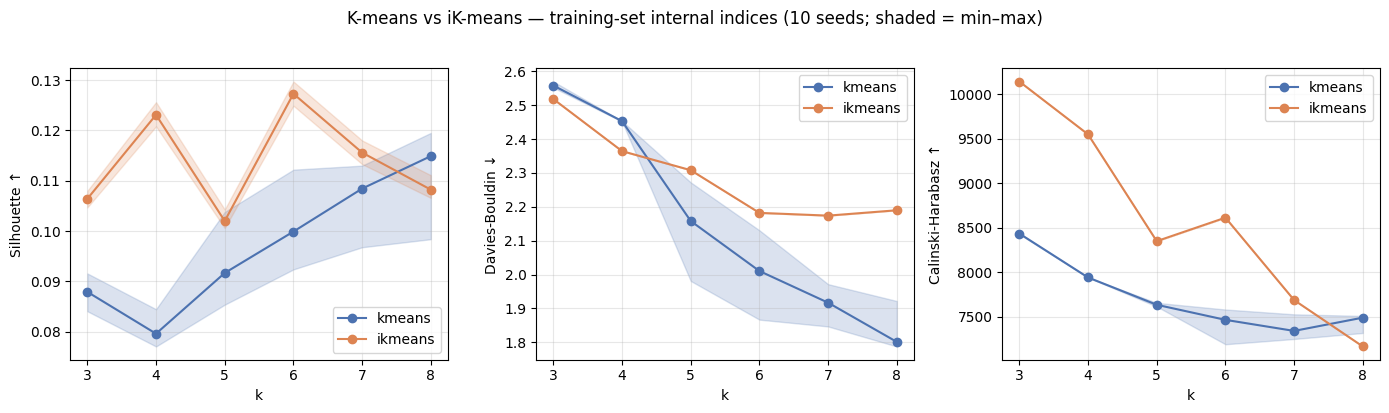

In [69]:
def plot_metric_comparison(frame, metric, ylabel, ax, lower_better=False):
    for method, color in [('kmeans', '#4C72B0'), ('ikmeans', '#DD8452')]:
        sub = frame[frame['method'] == method]
        if sub.empty:
            continue
        agg = sub.groupby('k')[metric].agg(['mean', 'min', 'max'])
        ax.fill_between(agg.index, agg['min'], agg['max'], alpha=0.2, color=color)
        ax.plot(agg.index, agg['mean'], marker='o', color=color, label=method)
    ax.set_xlabel('k')
    ax.set_ylabel(ylabel + (' ↓' if lower_better else ' ↑'))
    ax.grid(True, alpha=0.3)
    ax.legend()


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_metric_comparison(exp_now, 'silhouette_train',        'Silhouette',        axes[0])
plot_metric_comparison(exp_now, 'davies_bouldin_train',    'Davies-Bouldin',    axes[1], lower_better=True)
plot_metric_comparison(exp_now, 'calinski_harabasz_train', 'Calinski-Harabasz', axes[2])
plt.suptitle('K-means vs iK-means — training-set internal indices (10 seeds; shaded = min–max)', y=1.02)
plt.tight_layout()
fig.savefig('plots/baseline_metrics_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## Task 1.2.6 — First cluster-interpretation note

> **Brief Task 1.2 + Template §5:** *"Provide an initial interpretation of the resulting clusters (cluster profiles)."*

We pick k = 4 with the best-silhouette k-means seed and produce a short profile summary using the **raw, human-readable** feature values (not the standardised ones). This is first-pass interpretation; full per-cluster narrative goes in the final report.

In [70]:
K_PROFILE = 4
sub = exp_now[(exp_now['method'] == 'kmeans') & (exp_now['k'] == K_PROFILE)]
best_seed = int(sub.loc[sub['silhouette_train'].idxmax(), 'seed'])
print(f'Profiling k-means at k={K_PROFILE}, seed={best_seed} '
      f'(silhouette_train = {sub["silhouette_train"].max():.4f})')

labels_profile = kmeans_labels[(K_PROFILE, best_seed)]

# Per-cluster stats on the raw (pre-pipeline) numerical values
df_train_view = df.loc[X_train.index].copy()
df_train_view['cluster'] = labels_profile

interpret_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
                  'adults', 'total_of_special_requests', 'previous_cancellations']
profile_table = df_train_view.groupby('cluster')[interpret_cols].mean().round(2)
profile_table['size']     = df_train_view.groupby('cluster').size()
profile_table['size_pct'] = (profile_table['size'] / len(df_train_view) * 100).round(1)
profile_table = profile_table[['size', 'size_pct'] + interpret_cols]

print('\n=== Cluster profile (means, k=4, k-means) ===')
print(profile_table.to_string())

print('\n=== Hotel composition by cluster ===')
print(pd.crosstab(df_train_view['cluster'], df_train_view['hotel'], normalize='index')
      .round(3).mul(100).to_string())

print('\n=== Top market_segment per cluster (% within cluster) ===')
ms = pd.crosstab(df_train_view['cluster'], df_train_view['market_segment'],
                 normalize='index').mul(100).round(1)
print(ms.to_string())

# Post-hoc profiling against the held-out outcome variables
df_train_view['is_canceled'] = df_labels.loc[X_train.index, 'is_canceled'].values
print('\n=== Cancellation rate by cluster (POST-HOC profiling only) ===')
print(df_train_view.groupby('cluster')['is_canceled'].agg(['mean', 'count']).round(3).to_string())

Profiling k-means at k=4, seed=17348 (silhouette_train = 0.0845)

=== Cluster profile (means, k=4, k-means) ===
          size  size_pct  lead_time     adr  stays_in_week_nights  stays_in_weekend_nights  adults  total_of_special_requests  previous_cancellations
cluster                                                                                                                                              
0        29792      31.2     119.17   85.44                  2.15                     0.78    1.80                       0.39                    0.19
1        21897      23.0     110.69  148.37                  3.87                     1.59    2.13                       1.12                    0.00
2        40466      42.4      95.33   92.08                  2.10                     0.72    1.79                       0.41                    0.02
3         3213       3.4      30.09   64.98                  1.45                     0.43    1.39                       0.62             

**Initial reading.** <span style="color: #C2410C; font-weight: 600">[Fill in after running the cell above with a 2–4 line interpretation. Template asks: which clusters plausibly correspond to leisure-like or business-like patterns? Note the cancellation-rate post-hoc finding.]</span>

---

## Task 1.2.7 — Canonical cluster artefacts and decision checkpoint

Tasks 1.2.2–1.2.6 produced fits and metrics. This subsection turns them into the **single source of truth** every later section reads from: a canonical labelled dataframe, reusable profiling and comparison helpers, and a decision checkpoint.

Everything in Task 2 (alternative families), Task 3 (evaluation and robustness), and Task 3.4 (interpretation) consumes the artefacts built here.

### Task 1.2.7.1 — Selection rule and full-data labelling

> **Brief §1.2 requirement:** *"The final selection rule must be explicitly stated."*

**Selection rule for the baseline final model:**

For each method (k-means, iK-means), pick the `(k, seed)` combination with the **highest mean silhouette on training**, subject to a minimum cluster size of 1% of training rows (rejects degenerate partitions where one cluster collapses). If two `k` values tie within 0.005 silhouette, prefer the smaller k for interpretability.

The cell below applies this rule, refits the selected k-means model on `X_train`, predicts labels on the **full dataset** `X_df`, joins back the outcome variables held in `df_labels`, and writes `clusters.csv` as the canonical labelled frame.

This is the *"the answer is X"* cell — every interpretation downstream reads from `df_with_clusters` and from `clusters.csv`.

In [71]:
from dataclasses import dataclass


@dataclass
class ClusteringResult:
    'A single chosen run: which method/k/seed, the labels on the full dataset, the metrics.'
    method: str
    k: int
    seed: int
    run_id: str
    estimator: object              # fitted KMeans (or other sklearn-compatible estimator)
    labels_full: np.ndarray        # cluster id for every row in X_df
    metrics: dict                  # silhouette / DB / CH / runtime as logged
    representation_id: str


def _pick_best_kmeans(exp_now: pd.DataFrame, kmeans_labels: dict, X_train, min_cluster_pct=0.01):
    'Apply the §5.9.1 selection rule to k-means runs in experiments.csv.'
    candidates = exp_now[exp_now['method'] == 'kmeans'].copy()
    # mean silhouette per k
    mean_sil = candidates.groupby('k')['silhouette_train'].mean().sort_values(ascending=False)

    min_size = int(min_cluster_pct * len(X_train))
    for k in mean_sil.index:
        # Find the best seed within this k
        k_rows = candidates[candidates['k'] == k].sort_values('silhouette_train', ascending=False)
        for _, row in k_rows.iterrows():
            seed = int(row['seed'])
            labels = kmeans_labels.get((k, seed))
            if labels is None:
                continue
            sizes = pd.Series(labels).value_counts()
            if sizes.min() >= min_size:
                return int(k), seed, row
        # No seed at this k passed; try next k
    raise RuntimeError('No k-means run passed the minimum cluster-size threshold.')


k_final, seed_final, best_row = _pick_best_kmeans(exp_now, kmeans_labels, X_train)
print(f'Selected k-means: k={k_final}, seed={seed_final}, '
      f'silhouette_train={best_row["silhouette_train"]:.4f}')

# Refit on X_train with the chosen seed so we have a live estimator we can
# call .predict() on (the §5.4 loop didn't store the estimator object)
final_estimator = KMeans(n_clusters=k_final, init='k-means++', n_init=10,
                         random_state=seed_final).fit(X_train)

# Predict labels for the FULL dataset, not just the 80% train split
labels_full = final_estimator.predict(X_df)
print(f'Labelled {len(labels_full):,} rows (full dataset).')

# Build the canonical interpretation frame: features + outcomes + cluster
df_with_clusters = (
    df_features
      .join(df_labels)
      .assign(cluster=labels_full,
              split=np.where(df_features.index.isin(X_train.index), 'train', 'val'))
)

# Persist as a CSV artefact — every report figure can read from this file
Path('tables').mkdir(exist_ok=True)
df_with_clusters.to_csv('tables/clusters.csv', index=True)
print(f'Wrote tables/clusters.csv ({df_with_clusters.shape[0]} rows × {df_with_clusters.shape[1]} cols)')

# Wrap everything in a typed record so downstream cells stay tidy
final_result = ClusteringResult(
    method='kmeans',
    k=k_final,
    seed=seed_final,
    run_id=str(best_row['run_id']),
    estimator=final_estimator,
    labels_full=labels_full,
    metrics={
        'silhouette_train':        float(best_row['silhouette_train']),
        'davies_bouldin_train':    float(best_row['davies_bouldin_train']),
        'calinski_harabasz_train': float(best_row['calinski_harabasz_train']),
        'runtime_s':               float(best_row['runtime_s']),
    },
    representation_id=REPRESENTATION_ID,
)
print(f'\nfinal_result = {final_result.method} k={final_result.k} seed={final_result.seed} '
      f'run_id={final_result.run_id}')

Selected k-means: k=7, seed=17341, silhouette_train=0.1125
Labelled 119,210 rows (full dataset).
Wrote tables/clusters.csv (119210 rows × 29 cols)

final_result = kmeans k=7 seed=17341 run_id=49868ad3


### Task 1.2.7.2 — Reusable `profile_clusters` helper

> **Brief §3.4 requirement:** *"Provide cluster profiles with descriptive statistics and visual summaries."*

The function below produces the standard per-cluster summary you'll need in §6, Task 2, and Task 3.4. It returns a tidy DataFrame so it can be written straight to `tables/<name>.csv` for the LaTeX report.

Use it like this — same call, different inputs:

```python
profile_clusters(df_with_clusters)                    # baseline final
profile_clusters(df_with_ward_clusters)               # Ward, once executed
profile_clusters(df_with_noADR_clusters)              # §6 variant
```

In [72]:
def profile_clusters(
    frame: pd.DataFrame,
    label_col: str = 'cluster',
    num_features: list[str] | None = None,
    cat_features: list[str] | None = None,
    outcome_cols: list[str] | None = None,
) -> pd.DataFrame:
    '''Per-cluster descriptive profile.

    Returns one row per cluster with: size, size_pct, mean of each numerical
    feature, mode of each categorical feature, plus optional outcome means
    (e.g. cancellation rate). Designed to feed straight into a report table.
    '''
    num_features = num_features or [
        'lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
        'adults', 'children', 'total_of_special_requests', 'previous_cancellations',
    ]
    cat_features = cat_features or ['hotel', 'market_segment', 'customer_type',
                                    'distribution_channel', 'deposit_type']
    outcome_cols = outcome_cols or ['is_canceled']

    # Filter to columns that actually exist (so this works on subsetted frames too)
    num_features = [c for c in num_features if c in frame.columns]
    cat_features = [c for c in cat_features if c in frame.columns]
    outcome_cols = [c for c in outcome_cols if c in frame.columns]

    g = frame.groupby(label_col)
    rows = []
    for cluster_id, sub in g:
        row = {'cluster': cluster_id, 'size': len(sub),
               'size_pct': round(100 * len(sub) / len(frame), 1)}
        for col in num_features:
            row[f'mean_{col}'] = round(float(sub[col].mean()), 2)
        for col in cat_features:
            mode = sub[col].mode()
            top = mode.iloc[0] if not mode.empty else None
            top_pct = round(100 * (sub[col] == top).mean(), 1) if top is not None else None
            row[f'top_{col}'] = top
            row[f'top_{col}_pct'] = top_pct
        for col in outcome_cols:
            if pd.api.types.is_numeric_dtype(sub[col]):
                row[f'mean_{col}'] = round(float(sub[col].mean()), 3)
        rows.append(row)
    return pd.DataFrame(rows).set_index('cluster').sort_index()


# Worked call on the final baseline model
baseline_profile = profile_clusters(df_with_clusters)
print('=== Profile of final baseline model (k-means) ===')
print(baseline_profile.to_string())

# Persist for the report
baseline_profile.to_csv('tables/profile_baseline_kmeans.csv')
print('\nWrote tables/profile_baseline_kmeans.csv')

=== Profile of final baseline model (k-means) ===
          size  size_pct  mean_lead_time  mean_adr  mean_stays_in_week_nights  mean_stays_in_weekend_nights  mean_adults  mean_children  mean_total_of_special_requests  mean_previous_cancellations     top_hotel  top_hotel_pct top_market_segment  top_market_segment_pct top_customer_type  top_customer_type_pct top_distribution_channel  top_distribution_channel_pct top_deposit_type  top_deposit_type_pct  mean_is_canceled
cluster                                                                                                                                                                                                                                                                                                                                                                                                                              
0        49216      41.3           96.85    100.52                       2.00                          0.6

### Task 1.2.7.3 — `compare_solutions` — align and diff two clusterings

> **Brief §3.3 + §6.4:** the sensitivity comparison needs to answer not just *"are the labels similar?"* (ARI) but *"which cluster in A maps to which cluster in B?"* — otherwise the report can only say "ARI = 0.71" without describing what actually changed.

The function below:

1. Restricts both labellings to the intersection of their indices (handles the Ward subsample case).
2. Computes the ARI.
3. Aligns clusters using the **Hungarian assignment** on the cross-tabulation — the bijection that maximises overlap between the two labellings.
4. Returns the aligned cross-tab so you can see *"cluster 2 in A became cluster 0 in B, with 87% overlap"*.

Use it for: k-means vs iK-means, baseline vs §6 noADR variant, k-means vs Ward, etc.

In [73]:
from scipy.optimize import linear_sum_assignment


def compare_solutions(
    labels_a: np.ndarray | pd.Series,
    labels_b: np.ndarray | pd.Series,
    index_a: pd.Index | None = None,
    index_b: pd.Index | None = None,
    name_a: str = 'A',
    name_b: str = 'B',
) -> dict:
    '''Compare two clusterings on (possibly different) index sets.

    Returns:
        ari            : adjusted Rand index on the intersection
        n_compared     : number of rows in the intersection
        crosstab       : raw cross-tab (rows = A's clusters, cols = B's clusters)
        alignment      : list of (cluster_in_A, cluster_in_B, overlap_count, overlap_pct)
                         sorted by overlap descending — the Hungarian pairing
    '''
    sa = pd.Series(np.asarray(labels_a), index=index_a, name=name_a)
    sb = pd.Series(np.asarray(labels_b), index=index_b, name=name_b)
    common = sa.index.intersection(sb.index) if index_a is not None and index_b is not None else None
    if common is not None and len(common) > 0:
        sa, sb = sa.loc[common], sb.loc[common]
    elif len(sa) != len(sb):
        raise ValueError('Labels have different lengths and no index given to align on.')

    ari = float(adjusted_rand_score(sa, sb))
    ct = pd.crosstab(sa, sb)

    # Hungarian assignment to find the best A→B mapping
    # We want to maximise overlap, so feed -ct to a minimising algorithm
    cost = -ct.values
    # linear_sum_assignment requires square; pad with zeros if not
    nrow, ncol = cost.shape
    size = max(nrow, ncol)
    padded = np.zeros((size, size), dtype=cost.dtype)
    padded[:nrow, :ncol] = cost
    row_ind, col_ind = linear_sum_assignment(padded)

    alignment = []
    for r, c in zip(row_ind, col_ind):
        if r >= nrow or c >= ncol:
            continue  # padded slot
        a_label = ct.index[r]
        b_label = ct.columns[c]
        overlap = int(ct.iat[r, c])
        size_a = int(ct.iloc[r].sum())
        pct = round(100 * overlap / size_a, 1) if size_a else 0.0
        alignment.append({
            f'cluster_{name_a}': a_label,
            f'cluster_{name_b}': b_label,
            'overlap_count': overlap,
            'overlap_pct_of_A': pct,
        })

    return {
        'ari': round(ari, 4),
        'n_compared': int(len(sa)),
        'crosstab': ct,
        'alignment': pd.DataFrame(alignment).sort_values('overlap_count', ascending=False),
    }


# Worked call: compare k-means and iK-means at the chosen k on the train set
ik_labels = ikmeans_labels.get((k_final, seed_final))
if ik_labels is not None:
    cmp = compare_solutions(
        labels_a=kmeans_labels[(k_final, seed_final)],
        labels_b=ik_labels,
        index_a=X_train.index, index_b=X_train.index,
        name_a='kmeans', name_b='ikmeans',
    )
    print(f'k-means vs iK-means at k={k_final}, seed={seed_final}')
    print(f'  ARI         : {cmp["ari"]}')
    print(f'  n compared  : {cmp["n_compared"]:,}')
    print(f'\nAligned mapping (each row is one matched cluster pair):')
    print(cmp['alignment'].to_string(index=False))
    cmp['alignment'].to_csv('tables/compare_kmeans_vs_ikmeans.csv', index=False)
    print('\nWrote tables/compare_kmeans_vs_ikmeans.csv')
else:
    print(f'No iK-means run cached at (k={k_final}, seed={seed_final}); '
          'comparison skipped — happens if k > n_retained AP clusters.')

k-means vs iK-means at k=7, seed=17341
  ARI         : 0.0341
  n compared  : 95,368

Aligned mapping (each row is one matched cluster pair):
 cluster_kmeans  cluster_ikmeans  overlap_count  overlap_pct_of_A
              0                4          10588              26.9
              6                3           7077              27.1
              2                0           6708              57.2
              4                5           2665              58.5
              1                1           2018              70.5
              5                2            181               3.5
              3                6            101               1.8

Wrote tables/compare_kmeans_vs_ikmeans.csv


### Task 1.2.7.4 — Decision checkpoint

**Stop here and answer these before moving to §6.** Record the answers as bullet points below this cell; the report's Methods and Discussion sections will quote them verbatim.

1. **Is the final `(method, k, seed)` from §5.9.1 operationally sensible?** Look at the `baseline_profile` table from §5.9.2. Does each cluster have a recognisable narrative (premium leisure, corporate short-stay, etc.), or is one cluster a generic "everything else" bin? If unrecognisable, consider re-running with the next-best `k`.

2. **Cluster names.** Fill in the dict below with one short label per cluster id. These names propagate into every figure caption and table header from now on.

3. **K-means vs iK-means — same partition or different?** Look at the §5.9.3 ARI and alignment. If ARI > 0.8 and each k-means cluster has a clear iK-means counterpart with ≥80% overlap, the two methods agree and you can report iK-means as a validation of k-means rather than a competitor. If ARI < 0.5, they disagree substantively — flag it in the report.

4. **Hotel-as-feature decision.** Look at `baseline_profile['top_hotel']` and the `top_hotel_pct`. Are clusters dominated by one hotel (e.g. one cluster is 95% Resort)? If yes, the hotel split is doing most of the work and you should consider a §6 variant that excludes `hotel` from inputs.

```python
# Fill in after looking at baseline_profile, then re-run downstream cells:
CLUSTER_NAMES = {
    0: 'TODO — name this cluster',
    1: 'TODO',
    2: 'TODO',
    3: 'TODO',
    # ... one entry per cluster id
}
```

<span style="color: #C2410C; font-weight: 600">[TO DO — answer the four questions above and fill in CLUSTER_NAMES before running §6.]</span>

---

## §Task 3.3-Protocol — Stability and sensitivity (executed)

> **Brief §3.3** (full text in the Task 3.3 wrapper above). This subsection executes the protocol for k-means and iK-means; Task 2 reuses the same `KVALUES`, `SEEDS`, and helper functions for Ward / GMM / DBSCAN.

### Task 3.3.1 — Main representation

`{REPRESENTATION_ID}` — defined in §Task 1.1.4.

### Task 3.3.2 — Seeds

10 seeds, `range(17341, 17351)`. K-means and iK-means already ran in §Task 1.2 with these seeds; the same seed list will be reused for every variant in §Task 3.3.5.

### Task 3.3.3 — Stability measure: pairwise ARI across seeds

For each k and each method, we compute ARI between every pair of seed-induced train labellings and report **mean ARI across the pairs**.

- ARI ≈ 1 → highly stable across seeds
- ARI ≈ 0 → random with respect to each other
- ARI ≈ 0.6–0.8 → largely consistent with boundary fragmentation

### Task 3.3.4 — Planned controlled preprocessing variants

| # | `representation_id` suffix | Strategy | EDA evidence |
|---|---|---|---|
| (a) | `R-EUCLID-robust-...` | **RobustScaler** instead of StandardScaler | §3.5 skew, §3.10 \|z\| > 3 — Guidance slide 19 |
| (b) | `R-EUCLID-...-noADR-...` | **Drop ADR** from inputs (move to profiling-only) | Guidance slides 23–24 — required because ADR is in inputs |
| (c) | `R-EUCLID-...-cyclicMonth` | **Cyclic sin/cos encoding** for `arrival_date_month` (+ week + day) | §3.9 seasonality; Guidance slide 11 |
| (d) | `R-EUCLID-...-dropRedundant` | **Drop one of** `distribution_channel` / redundant pairs | §3.7 Cramér's V > 0.5 |

Each variant changes **one** preprocessing axis at a time (Brief §3.3 — "at least one controlled variant"; we run four for thorough robustness evidence).

### Task 3.3.6 — ARI stability on the executed baselines

We compute ARI for k-means and iK-means now, using the labels cached in §Task 1.2. The same helper is reused for every Task 2 family and every §Task 3.3.5 variant.

=== Pairwise ARI across seeds — K-MEANS ===
 k  n_pairs  ari_mean  ari_std  ari_min  ari_max
 3       45    0.9376   0.0646   0.8663   1.0000
 4       45    0.9958   0.0046   0.9891   1.0000
 5       45    0.8076   0.1716   0.5535   0.9988
 6       45    0.7289   0.1123   0.5690   0.9999
 7       45    0.8786   0.0985   0.6780   1.0000
 8       45    0.9120   0.1744   0.5632   1.0000

=== Pairwise ARI across seeds — iK-MEANS ===
 k  n_pairs  ari_mean  ari_std  ari_min  ari_max
 3       45       1.0      0.0      1.0      1.0
 4       45       1.0      0.0      1.0      1.0
 5       45       1.0      0.0      1.0      1.0
 6       45       1.0      0.0      1.0      1.0
 7       45       1.0      0.0      1.0      1.0
 8       45       1.0      0.0      1.0      1.0


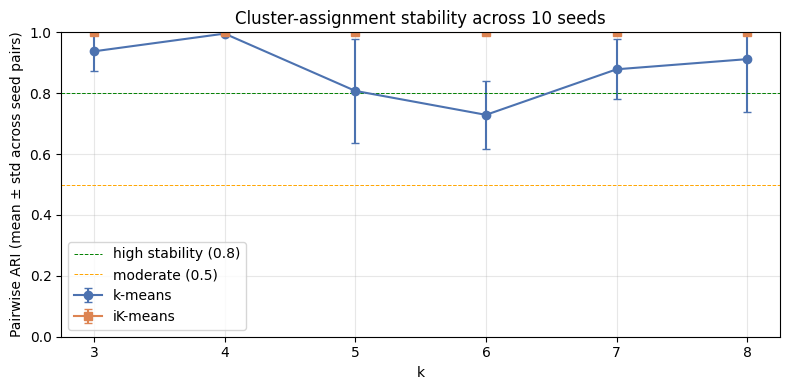

In [74]:
def pairwise_ari_per_k(labels_dict, kvalues, seeds):
    rows = []
    for k in kvalues:
        seed_labels = {s: labels_dict[(k, s)] for s in seeds if (k, s) in labels_dict}
        if len(seed_labels) < 2:
            continue
        aris = [adjusted_rand_score(seed_labels[a], seed_labels[b])
                for a, b in combinations(seed_labels.keys(), 2)]
        rows.append({
            'k': k,
            'n_pairs': len(aris),
            'ari_mean': round(float(np.mean(aris)), 4),
            'ari_std':  round(float(np.std(aris)), 4),
            'ari_min':  round(float(np.min(aris)), 4),
            'ari_max':  round(float(np.max(aris)), 4),
        })
    return pd.DataFrame(rows)


print('=== Pairwise ARI across seeds — K-MEANS ===')
ari_km = pairwise_ari_per_k(kmeans_labels, KVALUES, SEEDS)
print(ari_km.to_string(index=False))

print('\n=== Pairwise ARI across seeds — iK-MEANS ===')
ari_ik = pairwise_ari_per_k(ikmeans_labels, KVALUES, SEEDS)
print(ari_ik.to_string(index=False))


fig, ax = plt.subplots(figsize=(8, 4))
if not ari_km.empty:
    ax.errorbar(ari_km['k'], ari_km['ari_mean'], yerr=ari_km['ari_std'],
                marker='o', label='k-means', color='#4C72B0', capsize=3)
if not ari_ik.empty:
    ax.errorbar(ari_ik['k'], ari_ik['ari_mean'], yerr=ari_ik['ari_std'],
                marker='s', label='iK-means', color='#DD8452', capsize=3)
ax.axhline(0.8, color='green',  linestyle='--', linewidth=0.7, label='high stability (0.8)')
ax.axhline(0.5, color='orange', linestyle='--', linewidth=0.7, label='moderate (0.5)')
ax.set_xlabel('k')
ax.set_ylabel('Pairwise ARI (mean ± std across seed pairs)')
ax.set_title('Cluster-assignment stability across 10 seeds')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig('plots/stability_ari_baseline.png', dpi=200, bbox_inches='tight')
plt.show()

### Task 3.3.5 Executing the preprocessing variants

> <span style="color: #C2410C; font-weight: 600">**TO DO — code not yet written.**</span> This subsection needs four sub-pipelines, each building a different `X_df` and re-running k-means + iK-means over the 10 seeds and 6 k-values.

**Suggested implementation pattern** (one function, four calls):

```python
def build_representation(rep_id, scaler=StandardScaler(), include_adr=True,
                         cyclic_time=False, drop_redundant=False):
    'Return (X_df, representation_spec_dict) for the named variant.'
    # … build the pipeline with the supplied options …
    # … save artifacts/<rep_id>.json …
    return X_df_variant, spec

for rep_id, kwargs in VARIANTS.items():
    X_var, spec = build_representation(rep_id, **kwargs)
    run_baseline_and_log(X_var, rep_id, KVALUES, SEEDS)
```

**For each variant, report:**

1. Mean ± std of Silhouette / Davies-Bouldin / Calinski-Harabasz per k.
2. Pairwise ARI across seeds.
3. **Cross-variant ARI** — ARI between the baseline labelling and the variant's labelling, paired by seed. This is the *"does the variant change the clusters?"* number.
4. Whether the §5.8 cluster profile changes qualitatively (e.g. does the "premium leisure" cluster survive in `noADR`?).

**Decision rule (Brief §3.3):** *"Conclusions are robust only if metrics and interpretation are similar across the baseline and the variant. State explicitly whether the conclusion changes, and why."*

---

# Task 2 — Alternative Clustering Family

> **Brief §Task 2.1:** *"Choose one additional, conceptually distinct clustering family and implement it on the same representation: Agglomerative hierarchical (Ward/average/complete), Gaussian Mixture Model (EM) with AIC/BIC, or DBSCAN with correct parameter interpretation. Document the modelling choices and the final selection rule."*

> **Brief §Task 2.2:** *"Compare the baseline (Task 1.2) against the second family using the evaluation protocol defined in Task 3."*

The brief asks for *one* additional family. We implement **three** for the strongest possible comparative analysis:

- **Task 2.A — Ward hierarchical** is the **recommended primary alternative**. Euclidean-compatible (matches our representation), produces a dendrogram diagnostic, conceptually distinct from k-means.
- **Task 2.B — Gaussian Mixture Model** is the conceptual contrast: soft membership, probabilistic, AIC/BIC for model selection.
- **Task 2.C — DBSCAN** is included as an **explicit negative-result section**. Brief §5.2 warns that density-based clustering tends to fail on high-dim sparse OHE; honestly reporting that failure is a legitimate methodological contribution and answers RQ5.

All three are evaluated against the same Task 3 protocol (Task 3.1 indices, Task 3.2 family-specific diagnostics, Task 3.3 stability and sensitivity).

## Task 2.A — Ward hierarchical (RECOMMENDED PRIMARY ALTERNATIVE)

> <span style="color: #C2410C; font-weight: 600">**TO DO — code not yet written.**</span> Outline of the cells below:

**Cell — subsampling rule.** Ward is O(n²) in memory; with `X_train` at ~95k rows that's ~36 GB of distance matrix. Subsample to a manageable size:

```python
WARD_SAMPLE_SIZE = 10_000     # report this number in §Task 4
WARD_SAMPLE_SEED = 17341      # fixed; declared in §6.2
ward_idx = (np.random.default_rng(WARD_SAMPLE_SEED)
              .choice(X_train.index, size=WARD_SAMPLE_SIZE, replace=False))
X_ward = X_train.loc[ward_idx]
```

**Cell — Ward fit per k, single run (deterministic).** Loop `k ∈ KVALUES`, fit `AgglomerativeClustering(n_clusters=k, linkage='ward')`, score with the same `score_partition` helper, and log to `experiments.csv` with `method='ward'`, `seed=WARD_SAMPLE_SEED`, `sample_rule=f'ward_subsample_{WARD_SAMPLE_SIZE}_seed={WARD_SAMPLE_SEED}'`. Cache labels in `ward_labels[k]` (no seed dimension; Ward is deterministic).

**Cell — stability via subsample bootstrap** (Brief §3.3: *"for deterministic methods, replace random seeds with controlled resampling/perturbation"*). Draw 10 bootstrap subsamples of size 10k from `X_train`, refit Ward at the chosen k, compute pairwise ARI across the 10 bootstrap labellings (matched by overlap of indices).

**Cell — dendrogram** (Brief §3.2 family-specific diagnostic):

```python
from scipy.cluster.hierarchy import linkage, dendrogram
Z = linkage(X_ward.values, method='ward')  # ~10k rows; takes a minute
fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z, truncate_mode='level', p=6, ax=ax)
ax.set_title('Ward dendrogram (top 6 levels, n=10000 subsample)')
fig.savefig('plots/ward_dendrogram.png', dpi=200, bbox_inches='tight')
```

**Cell — cut rationale.** Markdown: explain the chosen cut height / number of clusters, referencing both the dendrogram structure and the internal indices.

**Cell — cross-method ARI.** Compute ARI between Ward labels and the best k-means / iK-means labels on the intersection of indices (the 10k Ward subsample). Answers: *do Ward and k-means find the same partition, or genuinely different ones?*

## Task 2.B — Gaussian Mixture Model (conceptual contrast)

> <span style="color: #C2410C; font-weight: 600">**TO DO — code not yet written.**</span> Outline:

**Caveat to address up front** in markdown: GMM assumes Gaussian components, but ~70 of our ~80 columns are binary one-hot. Strictly, the assumption is violated. We mitigate with `covariance_type='diag'` (per-dimension variances, no off-diagonal terms) and report the model-fit warning honestly in the discussion. An alternative is to fit GMM on a PCA-reduced version of the matrix; if you do that, treat it as Extension Module E4 (Brief §Extension Modules).

**Cell — GMM fit loop.** Per `(k, seed)`:

```python
gm = GaussianMixture(n_components=k, covariance_type='diag',
                     random_state=seed, n_init=5, reg_covar=1e-4)
gm.fit(X_train)
labels_train = gm.predict(X_train)
labels_val   = gm.predict(X_val)
# also record gm.bic(X_train) and gm.aic(X_train)
```

Log to `experiments.csv` with `method='gmm'` and extra notes columns for BIC/AIC.

**Cell — AIC/BIC curves** (Brief §3.2 family-specific diagnostic). Plot BIC vs k; the minimum (or elbow) is the model-selected k. Compare against the silhouette-implied k from §5.

**Cell — cross-method ARI** between best-BIC GMM labels and best k-means labels.

## Task 2.C — DBSCAN (explicit negative-result section)

> <span style="color: #C2410C; font-weight: 600">**TO DO — code not yet written.**</span> Outline:

**Framing in markdown.** Brief §5.2 explicitly warns: *"In high-dimensional sparse one-hot spaces, distances can become less informative; DBSCAN may yield one large cluster with many noise points, or almost all noise."* We expect DBSCAN to fail on our representation. Reporting that failure honestly — with the noise fraction documented and a discussion of why density doesn't transfer to sparse mixed data — is a legitimate methodological contribution and answers RQ5 (robustness to family choice).

**Cell — k-distance plot for `eps` selection** (Brief §3.2 family-specific diagnostic):

```python
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=10).fit(X_train.sample(20_000, random_state=17341))
dists, _ = nn.kneighbors(nn._fit_X)
k_dist = np.sort(dists[:, -1])
plt.plot(k_dist); plt.ylabel('10th-NN distance'); plt.title('k-distance plot')
# elbow → eps candidate
```

**Cell — DBSCAN grid.** Try 3–5 `(eps, min_samples)` combinations around the k-distance elbow. **Required by Brief §3.2 and §5.2**: *report the noise fraction for every run* (logged to the `noise_pct` column in `experiments.csv`).

**Cell — noise handling.** Brief §5.2: *"compute internal indices on non-noise points and report coverage = 1 − noise fraction"*. Drop noise points before silhouette/DB/CH and report both the coverage and the indices on the surviving points.

**Cell — interpretation.** Markdown: discuss whether the noise represents (i) data-quality anomalies, (ii) rare-but-plausible booking behaviour, or (iii) an artefact of high-dim distances on sparse OHE. Tie back to the brief's warning.

---

# Task 3 — Evaluation and Robustness Analysis

> **Brief §Task 3.** *"The following evaluation protocol is used consistently to compare the baseline (Task 1) and the alternative family (Task 2)."*

Task 3 has four sub-tasks. Two of them are already executed earlier in the notebook (because their code has to run alongside the fits); the other two consolidate the evidence in one place.

| Sub-task | Location in this notebook |
|---|---|
| 3.1 Internal validity indices | summary below (consolidates §Task 1.2 + §Task 2 indices) |
| 3.2 Family-specific diagnostics | summary below (cross-references each family's diagnostic) |
| 3.3 Stability and sensitivity analysis | executed earlier — see §Task 3.3 below |
| 3.4 Interpretation and communication | scaffolded below |

## Task 3.1 — Internal validity indices

> **Brief §3.1:** *"Report Silhouette score and at least one additional internal index (Calinski–Harabasz or Davies–Bouldin). All indices must be computed in the same representation and metric space used for clustering."*

All indices in this notebook are computed with **Euclidean distance in the `{REPRESENTATION_ID}` representation** (see §Task 1.1.4 metric sentence). Silhouette is sampled at 5000 points per run for tractability; Davies–Bouldin and Calinski–Harabasz use the full training set.

Indices reported per (method, k) — mean ± std across 10 seeds:

| Method | Location of the table |
|---|---|
| k-means | §Task 1.2.3 internal-indices summary |
| iK-means | §Task 1.2.3 internal-indices summary |
| Ward | §Task 2.A (once executed) |
| GMM | §Task 2.B (once executed) |
| DBSCAN | §Task 2.C (once executed; coverage = 1 − noise fraction also reported) |

<span style="color: #C2410C; font-weight: 600">**TO DO**</span> — after Task 2 is executed, consolidate the cross-method indices into one combined table here (`tables/all_methods_indices.csv`) for the report.

## Task 3.2 — Family-specific diagnostics

> **Brief §3.2:** *"Include at least one diagnostic appropriate to the selected model family: EM → AIC/BIC curves; DBSCAN/OPTICS → k-distance or reachability plots; Hierarchical → dendrogram and rationale for the cut."*

| Family | Diagnostic | Location |
|---|---|---|
| k-means | k-vs-metric curves with seed spread | §Task 1.2.4 (executed) |
| iK-means | natural-k from AP extraction + scatter_pct | §Task 1.2.2 (executed) |
| Ward | dendrogram + cut rationale | §Task 2.A (TODO) |
| GMM | AIC/BIC curves vs k | §Task 2.B (TODO) |
| DBSCAN | k-distance plot for ε selection + noise fraction | §Task 2.C (TODO) |

## Task 3.3 — Stability and sensitivity analysis

> **Brief §3.3:** *"Repeat the full pipeline for at least 5 random seeds. Report mean ± standard deviation of internal indices. Include at least one stability measure (e.g. ARI between runs). Include at least one controlled preprocessing variant and report the impact."*

The full Task 3.3 protocol (10 seeds, ARI stability, four controlled variants) is **executed earlier in this notebook**, inside §Task 3.3-Protocol below. The execution had to happen before Task 2 because Task 2 reuses the same `KVALUES`, `SEEDS`, and stability infrastructure.

→ Jump to §Task 3.3-Protocol (executed: ARI for k-means + iK-means; planned: four preprocessing variants)

## Task 3.4 — Interpretation and communication

> **Brief §3.4:** *"Provide cluster profiles with descriptive statistics and visual summaries. Indices alone are insufficient: link the clustering result to a meaningful 'booking profile' narrative that addresses the segmentation question, supported by evidence."*

> <span style="color: #C2410C; font-weight: 600">**TO DO — code not yet written.**</span> This subsection turns the §Task 1.2.5 first-pass note into a full per-cluster narrative on the **final chosen model** (decided after Task 3.3).

**Cells to write:**

1. **Final model selection.** Markdown: state which `(method, k, seed)` combination wins, based on combined evidence from internal indices (Task 3.1), stability (Task 3.3), and qualitative interpretability (§Task 1.2.5). Use the §Task 1.2.6 selection rule as the procedure.
2. **Per-cluster numerical profile.** Use the `profile_clusters` helper from §Task 1.2.6. Mean + median + std of every raw numerical feature, grouped by cluster. Visualised as a heatmap or radar plot.
3. **Per-cluster categorical profile.** Top categories per cluster (already produced by `profile_clusters`). Stacked-bar plot of `market_segment` and `customer_type` per cluster.
4. **Post-hoc outcome analysis.** Per-cluster cancellation rate and `reservation_status` distribution. **State explicitly in markdown that these are post-hoc and were not used in clustering** — this is a *finding*, not circular reasoning.
5. **Two-bookings worked example, revisited.** Pick one booking from each of two clusters and explain why their d² puts them in different clusters, referencing the §Task 1.1.4 worked-example structure.
6. **Narrative.** 200–300 words linking the discovered clusters to the RQ1 business/leisure framing. Be explicit about which clusters plausibly correspond to leisure vs business patterns, which are micro-segments, and which resist easy interpretation (no overclaiming).

---

# Task 4 — Reporting and reproducibility

> **Brief §Task 4.** Two parts: the academic report (4.1) and the repository scaffolding + experiment trace (4.2). The notebook supports both by saving every figure to `plots/`, every table to `tables/`, every representation to `artifacts/`, and every run to `experiments.csv`.

## Task 4.1 — Academic report (separate deliverable)

> <span style="color: #C2410C; font-weight: 600">**TO DO — outside this notebook.**</span> Brief §4.1: 6–8 pages single-column. Suggested sections: Abstract, Introduction, Dataset documentation, Methods, Experiments, Results, Discussion, Limitations/Ethics, References. The discussion must explicitly address (i) what was measured and why, (ii) how modelling choices were made, (iii) which evaluation protocol was followed, (iv) how results should be interpreted including limitations.

The report draws on this notebook for figures and tables. Each `plots/*.png` and each `tables/*.csv` maps to one report figure/table.

## Task 4.2 — Repository and experiment log

> **Brief §4.2 requirements** (template §7):

### 4.2.1 Repository hygiene checklist

- <span style="color: #C2410C; font-weight: 600">[ ] `README.md` at repo root with project description and dataset-acquisition instructions (raw dataset must **not** be committed — Brief §Dataset)</span>
- <span style="color: #C2410C; font-weight: 600">[ ] `environment.yml` or `requirements.txt` / lockfile with pinned versions</span>
- <span style="color: #C2410C; font-weight: 600">[ ] `run_all` entry point that regenerates every figure and table without manual steps (`jupyter nbconvert --execute main.ipynb` is sufficient if all artefacts land in `plots/`, `tables/`, and `artifacts/`)</span>
- <span style="color: #C2410C; font-weight: 600">[ ] Folder structure: `src/`, `figures/`, `tables/`, `artifacts/`, `experiments.csv`</span>
- <span style="color: #C2410C; font-weight: 600">[ ] Git tag `Submission` before the 5 June 2026 23:59 deadline</span>
- <span style="color: #C2410C; font-weight: 600">[ ] AI-tools disclosure in `README.md` (Brief §Academic Integrity)</span>
- <span style="color: #C2410C; font-weight: 600">[ ] Peer-review form submitted individually (Brief §Peer Review)</span>

### 4.2.2 Experiment log preview

The full experiment log is the audit trail for every result in the report (Brief §4.2: *"machine-readable experiment log with method, parameters, seeds, metrics, diagnostics, and notes"*). The schema and append helper were built early in the notebook (just before Task 1.2) so every fit logs through the same path.

In [75]:
exp_preview = load_experiments(EXPERIMENTS_PATH)
print(f'experiments.csv has {len(exp_preview)} rows.')
print(f'Methods logged: {sorted(exp_preview["method"].unique().tolist())}')
print(f'Representations logged: {sorted(exp_preview["representation_id"].unique().tolist())}')
print('\nFirst rows:')
display_cols = ['run_id', 'timestamp', 'representation_id', 'method', 'k', 'seed',
                'silhouette_train', 'davies_bouldin_train', 'runtime_s']
print(exp_preview[display_cols].head(8).to_string(index=False))

experiments.csv has 480 rows.
Methods logged: ['ikmeans', 'kmeans']
Representations logged: ['R-EUCLID-standard-countryRareRollup-withADR-logSkewed', 'rep_v1_baseline']

First rows:
  run_id                 timestamp representation_id method  k  seed  silhouette_train  davies_bouldin_train  runtime_s
471a8d33 2026-04-28T19:30:07+00:00   rep_v1_baseline kmeans  3 17341            0.0852                2.6462      0.229
f78363ed 2026-04-28T19:30:07+00:00   rep_v1_baseline kmeans  3 17342            0.0850                2.6421      0.191
1bd9da12 2026-04-28T19:30:08+00:00   rep_v1_baseline kmeans  3 17343            0.0704                3.0086      0.262
4b4a6555 2026-04-28T19:30:09+00:00   rep_v1_baseline kmeans  3 17344            0.0788                2.6870      0.293
2f8bc78e 2026-04-28T19:30:10+00:00   rep_v1_baseline kmeans  3 17345            0.0804                2.6867      0.258
6ce0a17a 2026-04-28T19:30:10+00:00   rep_v1_baseline kmeans  3 17346            0.0740            

---

# Extension Modules

> **Brief §Extension Modules.** *"The project grade combines two parts: Core (0–13 points) and Extensions (0–7 points), for a maximum of 20 points. Teams can obtain up to 13/20 using the Core tasks only. Grades above 13/20 require one or more Extension Modules and these must be integrated into the main experimental protocol and report narrative (not placed as an isolated appendix)."*

> **Brief — extension rules:**
> - Extensions must be methodologically correct, fully reproducible under the same standards as the Core, and explicitly linked to the research questions.
> - Extension experiments must follow the same project requirements (e.g. leakage control, feature governance, hyperparameter ranges, consistent distance/metric reporting).
> - If an extension involves randomness (e.g. k-NN graph construction, initializations), include a stability check with **at least 3 seeds** and report variability (e.g. mean ± std of key metrics).

## Recommendation summary

| Module | Goal | Cost given our setup | Recommendation |
|---|---|---|---|
| **E1 — Cluster-aware anomaly analysis** | Identify and interpret unusual bookings relative to learned clusters | **Low** — reuses existing k-means runs and `profile_clusters` | **Recommended (do this)** |
| **E2 — Spectral / graph clustering** | Apply spectral clustering with full graph specification | High — needs subsampling, eigensolver tuning, k-NN graph construction | Optional |
| **E3 — Fuzzy clustering + fuzzy validity** | Model soft memberships with fuzzy c-means and report fuzzy validity indices | Medium — `scikit-fuzzy` or custom implementation; results often inconclusive on sparse OHE | Optional |
| **E4 — PCA/SVD study for clustering** | Compare original vs reduced-dim representation | **Low** — `sklearn.decomposition.PCA` on existing `X_df` | **Recommended (do this)** |
| **E5 — Nonlinear DR for visualisation + reliability** | Use UMAP / t-SNE / Isomap to visualise clusters; report embedding reliability | Medium — needs trustworthiness diagnostic; supports the §Task 3.4 narrative | Recommended if §Task 3.4 needs visualisation |

**Suggested strategy:** do **E4 + E1** for a low-effort path to ~16–17/20. Add **E5** if you want strong figures for the report's interpretation section. E2 and E3 only make sense if you have surplus time after the Core is solid.

## E1 — Cluster-aware anomaly analysis (RECOMMENDED)

> **Brief §Module E1:** *"Identify and interpret unusual bookings as observations that are rare with respect to the learned cluster structure (i.e. anomalies are defined relative to clusters rather than as a separate anomaly-detection project)."*

### Required reporting (Brief §E1)

- [ ] **Anomaly score conditioned on clusters** — choose at least one of: distance to centroid/medoid normalised by cluster dispersion, low likelihood under a GMM, or noise label from DBSCAN/OPTICS.
- [ ] **Top-20 anomaly set** with a brief justification for each (why it is unusual).
- [ ] **Data-quality vs rare-but-plausible distinction** — flag impossible values separately from genuinely unusual booking patterns.
- [ ] **Sensitivity check** — show how the top-N set changes under at least one controlled representation/model change (e.g. RobustScaler variant from §Task 3.3, or k-means vs GMM).
- [ ] **Limitations discussion** — no ground-truth anomaly labels; risk of conflating "rare" with "bad".

### Implementation outline

> <span style="color: #C2410C; font-weight: 600">**TO DO — code not yet written.**</span> Reuses `final_result` and `profile_clusters` from §Task 1.2.7.

**Cell — anomaly scoring.** For each row, compute the distance to its cluster centroid in the standardised space, then z-normalise within the cluster so anomalies are comparable across clusters of different spread:

```python
centroids = final_result.estimator.cluster_centers_
sq_dist_to_own = ((X_df.values - centroids[final_result.labels_full]) ** 2).sum(axis=1)
# Normalise by per-cluster mean distance (avoids one big cluster swamping the ranking)
per_cluster_mean = pd.Series(sq_dist_to_own).groupby(final_result.labels_full).transform('mean')
anomaly_score = sq_dist_to_own / per_cluster_mean
```

**Cell — top-20 table.** Sort by `anomaly_score`, pick the top 20, join back to raw `df` for human-readable display. Include columns: `cluster`, `anomaly_score`, `lead_time`, `adr`, `stays_*`, `market_segment`, `country`, and `is_canceled` (post-hoc).

**Cell — data-quality vs rare-but-plausible split.** Apply rules:
- `adr` > 1000 or < 0 → data quality
- `adults + children + babies` == 0 → data quality (should have been removed in §Task 1.1.3, but verify)
- `lead_time` > 700 → likely data quality
- everything else → rare-but-plausible (real but unusual)

**Cell — sensitivity check.** Re-score anomalies using a §Task 3.3 variant (e.g. RobustScaler) and compute the **Jaccard overlap** between the two top-20 sets:

```python
top20_baseline = set(anomaly_score.nlargest(20).index)
top20_variant  = set(anomaly_score_robust.nlargest(20).index)
jaccard = len(top20_baseline & top20_variant) / len(top20_baseline | top20_variant)
```

Report Jaccard, plus the per-cluster anomaly-count distribution under each representation.

**Cell — narrative.** Markdown discussion of: (i) what the top-20 anomalies represent (one paragraph per archetype that emerges), (ii) which were data-quality artefacts vs unusual-but-real, (iii) what the sensitivity check says about the robustness of the anomaly set, (iv) explicit limitations (no labels; "rare" ≠ "bad").

**Artefacts to produce:** `tables/anomaly_top20_baseline.csv`, `tables/anomaly_top20_robust.csv`, `plots/anomaly_jaccard_comparison.png`.

## E2 — Spectral / graph clustering (optional, heavier)

> **Brief §Module E2:** *"Apply spectral clustering with a complete and well-specified graph construction and compare it against at least one Core method under the same evaluation protocol."*

### Required reporting (Brief §E2)

- [ ] **Graph construction** — specify k-NN vs mutual-kNN, value(s) of k, and the distance used in the chosen representation.
- [ ] **Edge weights** — connectivity (0/1) or heat-kernel weighting; justify any bandwidth parameter (σ).
- [ ] **Laplacian choice** — unnormalised or normalised; specify the eigen-solver configuration.
- [ ] **Embedding and clustering** — number of eigenvectors (eigengap or fixed rule), embedding normalisation (e.g. row-normalisation), final clustering method in the embedding (typically k-means).
- [ ] **Robustness** — small sensitivity analysis on k (graph) and/or weighting choice; comment on stability and interpretability.
- [ ] **Stability** — Brief requires ≥3 seeds for any randomness in graph construction or initialisation.

### Caveat for our setup

Spectral clustering on ~95k rows is **computationally hard**: the k-NN graph alone is O(n²) without an approximate method, and the eigendecomposition of the Laplacian is the bottleneck. Two routes:

1. **Subsample first** (consistent with Brief §5.1 subsampling rule), e.g. 10k rows like Ward. Document the rule.
2. **Use Nyström approximation** (`sklearn.cluster.SpectralClustering(affinity='nearest_neighbors')` already does the heavy lifting but still struggles past ~20k rows). Set `n_neighbors`, `assign_labels='kmeans'`, and document the choices.

### Implementation outline

> <span style="color: #C2410C; font-weight: 600">**TO DO — code not yet written.**</span>

**Cell — subsample + graph construction.**

```python
SPECTRAL_SAMPLE = 10_000
SPECTRAL_SEED = 17341
spec_idx = (np.random.default_rng(SPECTRAL_SEED)
              .choice(X_train.index, size=SPECTRAL_SAMPLE, replace=False))
X_spec = X_train.loc[spec_idx]

# Sensitivity: try k_neighbours ∈ (10, 30, 100)
from sklearn.cluster import SpectralClustering
sc = SpectralClustering(
    n_clusters=K_PROFILE,
    affinity='nearest_neighbors',
    n_neighbors=30,           # report this
    assign_labels='kmeans',
    random_state=SPECTRAL_SEED,
    n_init=10,
)
labels_spec = sc.fit_predict(X_spec)
```

**Cell — eigengap diagnostic.** Compute the Laplacian eigenvalues explicitly and plot the first ~15. The eigengap (largest jump) suggests a natural k. Compare against the Core k from §Task 1.2.

**Cell — stability across graph hyperparameters.** Loop over `n_neighbors ∈ (10, 30, 100)` and `random_state ∈ 3 seeds`; report ARI between every pair (using `compare_solutions` from §Task 1.2.7.3).

**Cell — cross-method ARI with k-means.** On the spectral subsample's index intersection with `X_train`, compute ARI between spectral labels and the matching k-means labels.

**Cell — narrative.** Discussion: did spectral discover the same structure as k-means? Was it sensitive to the graph hyperparameters? Was the subsampling rule a binding constraint on interpretability?

**Artefacts:** `plots/spectral_eigengap.png`, `tables/spectral_sensitivity_ari.csv`.

## E3 — Fuzzy clustering and fuzzy validity (optional)

> **Brief §Module E3:** *"Model soft cluster memberships (fuzzy c-means) and discuss membership uncertainty using fuzzy-appropriate validity criteria."*

### Required reporting (Brief §E3)

- [ ] **Fuzzy c-means run** with reported membership distributions; interpret **at least one case of ambiguous membership** (a booking with non-trivial probabilities across multiple clusters).
- [ ] **Fuzzy validity measure** — at least one of: Xie–Beni index, partition coefficient (PC), classification entropy (CE). Explain what it measures.
- [ ] **Comparison vs hard baseline** — compare the fuzzy solution to k-means in terms of cluster interpretation and stability.

### Caveat for our setup

Fuzzy c-means uses Euclidean distances, so it's compatible with our representation. The fuzzifier `m` (typically 1.5–2.5) controls how soft the assignments are; m → 1 reduces to hard k-means, m → ∞ assigns every point to every cluster equally. **You must report the m you used and justify it.** Standard choice: m = 2.

`scikit-fuzzy` provides `cmeans` and `cmeans_predict`. Install with `pip install scikit-fuzzy`. Note: scikit-fuzzy expects features as **rows** (transposed from sklearn's convention).

### Implementation outline

> <span style="color: #C2410C; font-weight: 600">**TO DO — code not yet written.**</span>

**Cell — fuzzy c-means fit.**

```python
import skfuzzy as fuzz

FCM_M = 2.0  # fuzzifier — justify in markdown
fcm_labels = {}
fcm_membership = {}

for k in KVALUES:
    for seed in SEEDS[:3]:  # ≥3 seeds per brief rule for randomness
        cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
            X_train.values.T,   # features as rows
            c=k, m=FCM_M, error=1e-5, maxiter=1000, seed=seed,
        )
        fcm_labels[(k, seed)] = u.argmax(axis=0)
        fcm_membership[(k, seed)] = u.T   # shape: (n_samples, n_clusters)
        # fpc = fuzzy partition coefficient (a fuzzy validity index)
        log_experiment({
            'method': 'fcm', 'k': k, 'seed': seed,
            'parameters': json.dumps({'m': FCM_M}),
            'notes': f'fpc={fpc:.4f}',
            # ... silhouette, DB, CH computed on hard labels
        })
```

**Cell — fuzzy validity indices.** Compute Xie–Beni, partition coefficient (PC), classification entropy (CE):

```python
def xie_beni(X, centroids, U, m):
    'Xie-Beni: lower is better.'
    n = X.shape[0]
    num = (U ** m * np.linalg.norm(X[:, None] - centroids, axis=2) ** 2).sum()
    min_centroid_dist_sq = np.min(np.sum((centroids[:, None] - centroids) ** 2, axis=2)[~np.eye(len(centroids), dtype=bool)])
    return num / (n * min_centroid_dist_sq)

def partition_coefficient(U):
    return (U ** 2).mean() * U.shape[1]

def classification_entropy(U):
    return -(U * np.log(np.clip(U, 1e-12, 1))).sum() / U.shape[0]
```

Plot all three vs k; the optimum is the elbow / min for XB and the max for PC.

**Cell — ambiguous-membership case study.** Find the booking with the highest entropy of its membership distribution (the most "in between") and print its features alongside the per-cluster probabilities. Markdown discussion of what this tells us about cluster boundaries.

**Cell — cross-method comparison.** Use `compare_solutions(fcm_labels[(k, seed)], kmeans_labels[(k, seed)], ...)` for ARI and alignment.

**Artefacts:** `tables/fcm_validity_indices.csv`, `tables/fcm_ambiguous_examples.csv`, `plots/fcm_validity_vs_k.png`.

## E4 — PCA/SVD study for clustering (RECOMMENDED)

> **Brief §Module E4:** *"Study representation learning for clustering (linear DR) and provide evidence for (or against) its usefulness on this dataset."*

### Required reporting (Brief §E4)

- [ ] **Dimensionality-reduction choice + justification** — PCA on dense features or TruncatedSVD on sparse one-hot. Retained dimensionality justified by explained-variance threshold (e.g. 90%).
- [ ] **Original vs reduced comparison** — same evaluation protocol (indices, stability) on both.
- [ ] **Mandatory caveat** — *"variance preservation is not guaranteed to preserve cluster-separating directions"*. The empirical evidence (whether clusters improve or degrade) must support whichever conclusion you draw.

### Why this is the cheapest extension for us

We already have `X_df` (standardised, mixed-type matrix, ~80 dims). PCA on it is two lines. Re-running k-means + iK-means in the reduced space reuses our existing loops with `X_train` replaced by `X_train_pca`. Stability via the same 10 seeds. Everything plugs into `experiments.csv` with a different `representation_id`.

### Implementation outline

> <span style="color: #C2410C; font-weight: 600">**TO DO — code not yet written.**</span>

**Cell — fit PCA, choose retained dims.**

```python
from sklearn.decomposition import PCA

pca = PCA(n_components=None, random_state=17341).fit(X_train)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_dims_90 = int(np.searchsorted(cum_var, 0.90) + 1)
print(f'Components for 90% variance: {n_dims_90}')
# Plot the scree curve
```

**Cell — build the reduced representation as a new `representation_id`.**

```python
PCA_REP_ID = f'R-EUCLID-pca{n_dims_90}-from-{REPRESENTATION_ID}'
pca_final = PCA(n_components=n_dims_90, random_state=17341).fit(X_train)
X_train_pca = pca_final.transform(X_train)
X_val_pca   = pca_final.transform(X_val)
X_df_pca    = pca_final.transform(X_df)

# Save the representation_spec artefact (parallels §Task 1.1.4.4)
pca_spec = {
    'representation_id': PCA_REP_ID,
    'parent_representation': REPRESENTATION_ID,
    'n_components': n_dims_90,
    'explained_variance_cumulative': float(cum_var[n_dims_90 - 1]),
    'note': 'PCA on standardised mixed-type matrix. Variance preservation does NOT '
            'guarantee preservation of cluster-separating directions (Brief §E4 caveat).',
}
# write to artifacts/<PCA_REP_ID>.json
```

**Cell — re-run k-means + iK-means on the reduced rep.** Same `KVALUES`, same `SEEDS`, same `log_experiment` calls — only `X_train` changes to `X_train_pca` and `representation_id` to `PCA_REP_ID`.

**Cell — comparison table.** Use `compare_solutions` to compute ARI between (baseline k-means at k=K_PROFILE, seed=best_seed) and (PCA k-means at the same k). If ARI > 0.8, PCA preserves the structure. If < 0.5, PCA changed the partition — discuss whether the change improved or degraded interpretability.

**Cell — narrative.** Required: state explicitly whether PCA helped, hurt, or made no difference, and tie it back to the brief's caveat. Possible findings:
- Indices improve, ARI to baseline high → PCA acts as noise reduction
- Indices improve, ARI low → PCA found a *different* but possibly better structure (interesting result)
- Indices degrade → variance preservation failed to preserve cluster-separating directions (the brief's caveat in action)
- Indices unchanged → PCA was redundant for this dataset

**Artefacts:** `plots/pca_scree.png`, `tables/pca_vs_baseline_indices.csv`, `tables/pca_vs_baseline_compare.csv`, `artifacts/{PCA_REP_ID}.json`.

## E5 — Nonlinear DR for visualisation & embedding reliability (recommended if §Task 3.4 needs figures)

> **Brief §Module E5:** *"Use nonlinear dimensionality reduction to support interpretation (visualisation), while explicitly discussing embedding reliability."*

### Required reporting (Brief §E5)

- [ ] **One nonlinear DR method** chosen from: MDS, Isomap, LLE, t-SNE, UMAP. **For visualisation only** — do not present clustering performed solely on the nonlinear embedding as the main result (Brief §E5).
- [ ] **Trustworthiness diagnostic** — report `sklearn.manifold.trustworthiness` between the original and embedded spaces, or run a parameter sensitivity study and discuss how conclusions depend on hyperparameters.
- [ ] **Use the visualisation to support cluster interpretation** — colour points by their Core-method cluster label (from §Task 1.2.7), not by a re-clustering of the embedding.

### Why this fits §Task 3.4

The final cluster narrative in §Task 3.4 needs a 2D figure showing the discovered clusters in feature space. A scatter of `X_df_umap` coloured by `final_result.labels_full` is exactly that figure. Without an embedding, we can only show per-feature distributions; with UMAP / t-SNE we can show the cluster geometry.

### Method choice

| Method | Pros | Cons |
|---|---|---|
| **UMAP** | Fast (handles 100k+), preserves global structure better than t-SNE | Pip-install only (not in stdlib sklearn); hyperparameter-sensitive |
| **t-SNE** | Built into sklearn, well-known | Slow on >50k rows; global distances meaningless |
| **Isomap** | Theoretically principled (geodesic distances) | O(n²) without subsampling; slower than UMAP |
| **MDS** | Simple to explain | Often produces uninformative blobs on high-dim mixed data |

**Recommendation: UMAP.** It scales to our data size and integrates cleanly with the matplotlib scatter plots used elsewhere. If UMAP install is a problem, fall back to t-SNE on a 20k subsample.

### Implementation outline

> <span style="color: #C2410C; font-weight: 600">**TO DO — code not yet written.**</span>

**Cell — fit UMAP.**

```python
import umap  # pip install umap-learn

UMAP_SEED = 17341
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,        # report this; sensitivity check below
    min_dist=0.1,          # report this
    random_state=UMAP_SEED,
    metric='euclidean',
)
X_train_umap = reducer.fit_transform(X_train)
X_df_umap = reducer.transform(X_df)
```

**Cell — trustworthiness diagnostic.**

```python
from sklearn.manifold import trustworthiness
trust = trustworthiness(X_train.values, X_train_umap, n_neighbors=10)
print(f'Trustworthiness: {trust:.4f}  (1.0 = perfect, > 0.9 = good)')
```

**Cell — parameter sensitivity study.** Re-fit UMAP with `n_neighbors ∈ {15, 30, 100}` and `min_dist ∈ {0.0, 0.1, 0.5}`. Plot a 3×3 grid of scatter plots coloured by `final_result.labels_full`. **Required**: a paragraph discussing how cluster appearance changes with these hyperparameters.

**Cell — main visualisation.** Single 2D scatter of `X_df_umap` coloured by cluster, with cluster centroids and named labels (from §Task 1.2.7.4 `CLUSTER_NAMES`). This is the figure that goes in the report's interpretation section.

**Cell — narrative.** Required: connect the UMAP geometry to the §Task 1.2.7.2 cluster profile. Where clusters overlap in UMAP, look at the profile to explain why (often: shared categorical values like `market_segment=Online TA`). Where clusters are well-separated, note which features drove the separation.

**Caveat to address explicitly** (required by Brief §E5): UMAP distances are NOT meaningful; only the relative arrangement of points matters. Do not interpret "cluster A is closer to cluster B than to cluster C" in the UMAP plot as a feature-space claim — it's an embedding artefact.

**Artefacts:** `plots/umap_clusters.png`, `plots/umap_sensitivity_grid.png`, `tables/umap_trustworthiness.csv`.

---

## Appendix — index of Brief tasks and template artefacts

| Brief task | Template §  | Location in this notebook |
|---|---|---|
| Task 1.1 — Data preparation and validation pipeline | §§1, 2, 3, 4 | §§Task 1.1.1 → 1.1.4 |
| Task 1.2 — Baseline clustering (k-means + iK-means) | §5 | §Task 1.2 |
| Task 2 — Alternative clustering family | — | §Task 2 (Ward / GMM / DBSCAN) |
| Task 3.1 — Internal validity indices | — | §Task 3.1 (summary across all methods) |
| Task 3.2 — Family-specific diagnostics | — | §Task 3.2 |
| Task 3.3 — Stability and sensitivity | §6 | §Task 3.3 |
| Task 3.4 — Interpretation and communication | — | §Task 3.4 |
| Task 4.1 — Academic report (6–8 pages) | — | outside notebook |
| Task 4.2 — Repository and experiment log | §7 | §Task 4.2 |

**Plots written to `plots/`:** `baseline_metrics_comparison.png`, `stability_ari_baseline.png`, *(planned)* `ward_dendrogram.png`, `gmm_bic_curve.png`, `dbscan_kdistance.png`.

**Artefacts written to `artifacts/`:** `R-EUCLID-standard-countryRareRollup-withADR-logSkewed.json`, plus one JSON per Task 3.3 variant once executed.

**Tables written to `tables/`:** `clusters.csv` (full-data labelled frame), `profile_baseline_kmeans.csv`, `compare_kmeans_vs_ikmeans.csv`, plus per-variant profile / comparison tables once §Task 3.3 is executed.